#Association Task

**Objective**

Identify structural associations between wealth accumulation and national well-being indicators. We aim to extract association rules that link sectors of wealth generation with country-level social and economic indicators. For example:

* Are there sectors that are frequently associated with countries where life expectancy is low but fiscal revenues are high?
* Are specific industries more prevalent in countries experiencing high volatility in the Consumer Price Index (CPI)?
* Do some sectors consistently appear in countries with stronger social indicators?

This approach could help reveal potential “human costs” or structural trade-offs embedded in certain sectors. For instance, we may find that technological industries are commonly associated with higher life expectancy and macroeconomic stability, while other sectors are linked to higher inflation or weaker welfare indicators.


# Libraries

In [ ]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Load clean dataset

In [ ]:
dataset_url = "https://raw.githubusercontent.com/nmart1nezl/DataMiningProject/refs/heads/main/datasets/dataset_cleaned.csv"
df = pd.read_csv(dataset_url)
df.head()

,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,selfMade,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,associated_companies,number_of_companies
0,211000,Fashion & Retail,Bernard Arnault & family,74.080767,France,Paris,Retail and Consumer Goods,Consumer Discretionary,France,False,...,1.1,2.715518e+12,65.6,102.5,82.5,24.2,60.7,67059887.0,"LVMH (Louis Vuitton, Dior, Givenchy, Tiffany &...",75
1,180000,Automotive,Elon Musk,51.767283,United States,Austin,Technology,Consumer Discretionary,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Tesla, SpaceX, X (Twitter), Starlink, The Bori...",7
2,114000,Technology,Jeff Bezos,59.225188,United States,Medina,Technology,Technology & Telecommunications,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Amazon, Blue Origin, The Washington Post, Bezo...",100
3,107000,Technology,Larry Ellison,78.628337,United States,Lanai,Technology,Technology & Telecommunications,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Oracle, Tesla (stake), NetSuite, Sensei Ag, Pa...",5
4,106000,Finance & Investments,Warren Buffett,92.594114,United States,Omaha,Finance and Investments,Financials & Investments,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Berkshire Hathaway (GEICO, Duracell, Dairy Que...",60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2638 entries, 0 to 2637
Data columns (total 27 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   finalWorth                                  2638 non-null   int64  
 1   category                                    2638 non-null   object 
 2   personName                                  2638 non-null   object 
 3   age                                         2638 non-null   float64
 4   country                                     2638 non-null   object 
 5   city                                        2638 non-null   object 
 6   source                                      2638 non-null   object 
 7   industries                                  2598 non-null   object 
 8   countryOfCitizenship                        2638 non-null   object 
 9   selfMade                                    2638 non-null   bool   
 10  status      

# **First method: Apriori**

## Transformación del Dataset a Nivel de País para Minería de Reglas de Asociación

### Paso 1 & 2A: Estructura del Sector (Share de Industria por País y Binning Cuantil)


### Paso 2A: Estructura del Sector (Share de Industria por País y Binning Cuantil)


Crearemos una matriz de tabla cruzada normalizada para obtener la proporción de cada industria dentro de cada país. Luego, para cada industria, categorizaremos estas proporciones en 'baja', 'media' o 'alta' utilizando cuartiles.

In [ ]:
# Inicializar country_features_df una vez al principio de la construcción de características
country_features_df = pd.DataFrame(index=df['country'].unique())
country_features_df.index.name = 'country'

In [ ]:
# --- 2A. Estructura del Sector (Ajustado para evitar ceros dominantes) ---
industry_shares = pd.crosstab(index=df['country'], columns=df['industries'], normalize='index')
binned_industry_features = pd.DataFrame(index=industry_shares.index)

for col in industry_shares.columns:
    series = industry_shares[col]

    # Crear una serie de strings inicializada con 'none' para los ceros
    binned = pd.Series('none', index=series.index, dtype='object')

    # Filtrar solo valores positivos
    positive_values = series[series > 0]

    if not positive_values.empty:
        num_unique = positive_values.nunique()

        if num_unique == 1:
            binned.loc[series > 0] = 'high'
        else:
            # Aplicar qcut solo a los valores positivos
            try:
                q_labels = ['low', 'mid', 'high']
                # Ajustar etiquetas si hay pocos valores únicos
                current_labels = q_labels[-max(1, min(3, num_unique)):]

                binned_positive = pd.qcut(
                    positive_values,
                    q=min(3, num_unique),
                    labels=current_labels,
                    duplicates='drop'
                )
                binned.loc[positive_values.index] = binned_positive.astype(str)
            except Exception as e:
                binned.loc[series > 0] = 'high'

    binned_industry_features[f'share_{col.lower().replace(" ", "_")}_bin'] = binned.astype('category')

country_features_df = country_features_df.drop(columns=[c for c in country_features_df.columns if 'share_' in c and '_source_' not in c], errors='ignore')
country_features_df = country_features_df.merge(binned_industry_features, left_index=True, right_index=True, how='left')

print("Estructura de sector binned (ceros como 'none'):")
display(country_features_df[[c for c in country_features_df.columns if 'share_' in c and '_source_' not in c]].head())


Estructura de sector binned (ceros como 'none'):


,share_consumer_discretionary_bin,share_consumer_staples_bin,share_energy_&_natural_resources_bin,share_financials_&_investments_bin,share_healthcare_bin,share_industrials_&_manufacturing_bin,"share_media,_entertainment_&_leisure_bin",share_other_bin,share_real_estate_&_construction_bin,share_technology_&_telecommunications_bin
country,,,,,,,,,,
France,mid,high,low,low,mid,low,none,mid,mid,low
United States,mid,mid,mid,mid,low,low,mid,low,low,mid
Mexico,low,high,none,low,none,mid,none,mid,low,low
India,mid,mid,none,low,high,mid,low,mid,mid,mid
Spain,high,mid,none,mid,none,mid,none,none,high,none


### Paso 2A.1: Estructura de la Fuente (Share de Fuente por País y Binning Cuantil)

De manera similar a las industrias, crearemos una matriz de tabla cruzada normalizada para obtener la proporción de cada 'source' (fuente de riqueza) dentro de cada país. Luego, para cada fuente, categorizaremos estas proporciones en 'baja', 'media' o 'alta' utilizando cuartiles.

In [ ]:
# --- 2A.1. Estructura de la Fuente (Ajustado para evitar ceros dominantes) ---
source_shares = pd.crosstab(index=df['country'], columns=df['source'], normalize='index')
binned_source_features = pd.DataFrame(index=source_shares.index)

for col in source_shares.columns:
    series = source_shares[col]
    binned = pd.Series('none', index=series.index, dtype='object')
    positive_values = series[series > 0]

    if not positive_values.empty:
        num_unique = positive_values.nunique()
        if num_unique == 1:
            binned.loc[series > 0] = 'high'
        else:
            try:
                q_labels = ['low', 'mid', 'high']
                current_labels = q_labels[-max(1, min(3, num_unique)):]
                binned_positive = pd.qcut(positive_values, q=min(3, num_unique), labels=current_labels, duplicates='drop')
                binned.loc[positive_values.index] = binned_positive.astype(str)
            except:
                binned.loc[series > 0] = 'high'

    binned_source_features[f'share_{col.lower().replace(" ", "_")}_source_bin'] = binned.astype('category')

country_features_df = country_features_df.drop(columns=[c for c in country_features_df.columns if '_source_bin' in c], errors='ignore')
country_features_df = country_features_df.merge(binned_source_features, left_index=True, right_index=True, how='left')

print("Estructura de fuente binned (ceros como 'none'):")
display(country_features_df[[c for c in country_features_df.columns if '_source_bin' in c]].head())


Estructura de fuente binned (ceros como 'none'):


,share_energy_and_utilities_source_bin,share_finance_and_investments_source_bin,share_food_and_agriculture_source_bin,share_healthcare_and_pharmaceuticals_source_bin,share_manufacturing_and_industrial_source_bin,share_media_and_entertainment_source_bin,share_mining_and_materials_source_bin,share_other_source_bin,share_real_estate_and_construction_source_bin,share_retail_and_consumer_goods_source_bin,share_technology_source_bin,share_transportation_and_logistics_source_bin
country,,,,,,,,,,,,
France,none,mid,high,mid,low,none,none,mid,none,mid,low,mid
United States,mid,mid,mid,low,low,mid,low,low,low,mid,mid,low
Mexico,none,mid,high,none,mid,none,none,none,high,none,low,none
India,low,low,low,high,mid,none,none,low,low,mid,mid,low
Spain,none,high,high,none,none,none,none,high,high,mid,none,none


### Paso 2B: Estructura de la Riqueza (Total, Promedio, por Capita, Ratio GDP, y Binning Cuantil)

Calcularemos diversas métricas de riqueza a nivel de país, como la riqueza total, el promedio por billonario, la cantidad de billonarios, y la riqueza en relación con la población y el PIB. Todas estas métricas serán categorizadas en 'baja', 'media' o 'alta'.

In [ ]:
# Agrupar el DataFrame original para calcular métricas a nivel de país
country_wealth_metrics = df.groupby('country').agg(
    average_wealth=('finalWorth', 'mean'),
    num_billionaires=('personName', 'nunique'),
    population_country=('population_country', 'first'),
    gdp_country=('gdp_country', 'first'),
    total_wealth_aux=('finalWorth', 'sum') # Solo para calcular ratios
).reset_index()

# Calcular riqueza por capita y riqueza a ratio de GDP
country_wealth_metrics['wealth_per_capita'] = country_wealth_metrics['total_wealth_aux'] / country_wealth_metrics['population_country']
country_wealth_metrics['wealth_to_gdp_ratio'] = country_wealth_metrics['total_wealth_aux'] / country_wealth_metrics['gdp_country']

# Eliminar columnas auxiliares y total_wealth para evitar redundancia
country_wealth_metrics = country_wealth_metrics.drop(columns=['population_country', 'gdp_country', 'total_wealth_aux'])

# --- Binning de Variables ---

# 1. Caso Especial: num_billionaires con bins manuales
bins_nb = [0, 5, 20, 100, np.inf]
labels_nb = ['very_few', 'few', 'many', 'extreme']
country_wealth_metrics['num_billionaires_bin'] = pd.cut(
    country_wealth_metrics['num_billionaires'],
    bins=bins_nb,
    labels=labels_nb,
    include_lowest=True
)

# 2. Caso Especial: wealth_to_gdp_ratio con thresholds económicos
bins_gdp_ratio = [0, 0.01, 0.05, 0.15, np.inf]
labels_gdp_ratio = ['low_influence', 'moderate_influence', 'high_influence', 'extreme_influence']
country_wealth_metrics['wealth_to_gdp_ratio_bin'] = pd.cut(
    country_wealth_metrics['wealth_to_gdp_ratio'],
    bins=bins_gdp_ratio,
    labels=labels_gdp_ratio,
    include_lowest=True
)

# 3. Resto de variables con binning estándar (3 bins)
wealth_bins = ['low_wealth', 'mid_wealth', 'high_wealth']
for col in ['average_wealth', 'wealth_per_capita']:
    col_data = country_wealth_metrics[col].fillna(country_wealth_metrics[col].median())

    if col_data.nunique() > 1:
        country_wealth_metrics[f'{col}_bin'] = pd.qcut(
            col_data,
            q=3,
            labels=wealth_bins,
            duplicates='drop'
        )
    else:
        country_wealth_metrics[f'{col}_bin'] = wealth_bins[0]

# Fusionar con el DataFrame principal de características de país
# Eliminamos bins antiguos para evitar conflictos
country_features_df = country_features_df.drop(columns=['total_wealth_bin', 'average_wealth_bin', 'num_billionaires_bin', 'wealth_per_capita_bin', 'wealth_to_gdp_ratio_bin'], errors='ignore')
country_features_df = country_features_df.merge(country_wealth_metrics[['country', 'average_wealth_bin', 'num_billionaires_bin', 'wealth_per_capita_bin', 'wealth_to_gdp_ratio_bin']], on='country', how='left')
country_features_df = country_features_df.set_index('country')

print("Distribución de métricas de riqueza (sin total_wealth):")
display(country_features_df.head())

Distribución de métricas de riqueza (sin total_wealth):


,share_consumer_discretionary_bin,share_consumer_staples_bin,share_energy_&_natural_resources_bin,share_financials_&_investments_bin,share_healthcare_bin,share_industrials_&_manufacturing_bin,"share_media,_entertainment_&_leisure_bin",share_other_bin,share_real_estate_&_construction_bin,share_technology_&_telecommunications_bin,...,share_mining_and_materials_source_bin,share_other_source_bin,share_real_estate_and_construction_source_bin,share_retail_and_consumer_goods_source_bin,share_technology_source_bin,share_transportation_and_logistics_source_bin,average_wealth_bin,num_billionaires_bin,wealth_per_capita_bin,wealth_to_gdp_ratio_bin
country,,,,,,,,,,,,,,,,,,,,,
France,mid,high,low,low,mid,low,none,mid,mid,low,...,none,mid,none,mid,low,mid,high_wealth,many,high_wealth,low_influence
United States,mid,mid,mid,mid,low,low,mid,low,low,mid,...,low,low,low,mid,mid,low,high_wealth,extreme,high_wealth,low_influence
Mexico,low,high,none,low,none,mid,none,mid,low,low,...,none,none,high,none,low,none,high_wealth,few,mid_wealth,low_influence
India,mid,mid,none,low,high,mid,low,mid,mid,mid,...,none,low,low,mid,mid,low,mid_wealth,extreme,mid_wealth,low_influence
Spain,high,mid,none,mid,none,mid,none,none,high,none,...,none,high,high,mid,none,none,high_wealth,many,high_wealth,low_influence


### Paso 2C: Desigualdad / Concentración (Top Wealth Share y Binning Cuantil)

Calcularemos la proporción de la riqueza total que posee el billonario más rico de cada país (`top_wealth_share`) y la categorizaremos en 'baja', 'media' o 'alta'.

In [ ]:
# Calcular top_wealth_share por país
# Necesitamos el total de riqueza y la riqueza máxima por país del df original

country_inequality = df.groupby('country').agg(
    total_country_wealth=('finalWorth', 'sum'),
    max_person_wealth=('finalWorth', 'max')
).reset_index()

country_inequality['top_wealth_share'] = country_inequality['max_person_wealth'] / country_inequality['total_country_wealth']

# --- Binning de Variables con Umbrales Económicos ---
inequality_bins_edges = [0, 0.2, 0.4, 0.7, 1.0]
inequality_labels = ['low_concentration', 'mid_concentration', 'high_concentration', 'extreme_oligarchy']

# Manejar NaN antes de cut
country_inequality['top_wealth_share'] = country_inequality['top_wealth_share'].fillna(country_inequality['top_wealth_share'].median())

country_inequality['top_wealth_share_bin'] = pd.cut(
    country_inequality['top_wealth_share'],
    bins=inequality_bins_edges,
    labels=inequality_labels,
    include_lowest=True
)

# Fusionar con el DataFrame principal de características de país
# Eliminamos la columna si ya existe para evitar duplicados (.on merge)
country_features_df = country_features_df.drop(columns=['top_wealth_share_bin'], errors='ignore')
country_features_df = country_features_df.merge(country_inequality[['country', 'top_wealth_share_bin']], on='country', how='left')
country_features_df = country_features_df.set_index('country')

print("Distribución de top_wealth_share con nuevos bins:")
print(country_inequality['top_wealth_share_bin'].value_counts())
display(country_features_df.head())

Distribución de top_wealth_share con nuevos bins:
top_wealth_share_bin
extreme_oligarchy     25
low_concentration     20
mid_concentration     17
high_concentration    17
Name: count, dtype: int64


,share_consumer_discretionary_bin,share_consumer_staples_bin,share_energy_&_natural_resources_bin,share_financials_&_investments_bin,share_healthcare_bin,share_industrials_&_manufacturing_bin,"share_media,_entertainment_&_leisure_bin",share_other_bin,share_real_estate_&_construction_bin,share_technology_&_telecommunications_bin,...,share_other_source_bin,share_real_estate_and_construction_source_bin,share_retail_and_consumer_goods_source_bin,share_technology_source_bin,share_transportation_and_logistics_source_bin,average_wealth_bin,num_billionaires_bin,wealth_per_capita_bin,wealth_to_gdp_ratio_bin,top_wealth_share_bin
country,,,,,,,,,,,,,,,,,,,,,
France,mid,high,low,low,mid,low,none,mid,mid,low,...,mid,none,mid,low,mid,high_wealth,many,high_wealth,low_influence,high_concentration
United States,mid,mid,mid,mid,low,low,mid,low,low,mid,...,low,low,mid,mid,low,high_wealth,extreme,high_wealth,low_influence,low_concentration
Mexico,low,high,none,low,none,mid,none,mid,low,low,...,none,high,none,low,none,high_wealth,few,mid_wealth,low_influence,high_concentration
India,mid,mid,none,low,high,mid,low,mid,mid,mid,...,low,low,mid,mid,low,mid_wealth,extreme,mid_wealth,low_influence,low_concentration
Spain,high,mid,none,mid,none,mid,none,none,high,none,...,high,high,mid,none,none,high_wealth,many,high_wealth,low_influence,high_concentration


### Paso 2D: Diversificación Económica (Entropía de Distribución del Sector y Binning Cuantil)

Calcularemos la entropía de Shannon para la distribución de sectores por país, lo que nos dará una medida de la diversificación económica. Una entropía más alta indica una mayor diversificación. Luego, la categorizaremos en 'baja', 'media' o 'alta'.

In [ ]:
from scipy.stats import entropy

# Usar industry_shares del Paso 2A
country_diversity = pd.DataFrame(index=industry_shares.index)

# Calcular la entropía de la distribución del sector por país
# Rellenar NaNs con 0 antes de calcular la entropía para que las proporciones sumen 1 o manejar la ausencia de una industria
country_diversity['sector_entropy'] = industry_shares.apply(lambda x: entropy(x.fillna(0)), axis=1)

# Binning en 3 categorías
diversity_bins = ['low_diversity', 'mid_diversity', 'high_diversity']

# Manejar NaN antes de qcut (si algún país no tiene datos de industria, su entropía puede ser NaN)
country_diversity['sector_entropy'] = country_diversity['sector_entropy'].fillna(country_diversity['sector_entropy'].median())

if country_diversity['sector_entropy'].nunique() > 1:
    country_diversity['sector_entropy_bin'] = pd.qcut(
        country_diversity['sector_entropy'],
        q=3,
        labels=diversity_bins,
        duplicates='drop'
    )
else:
    country_diversity['sector_entropy_bin'] = diversity_bins[0]

# Fusionar con el DataFrame principal de características de país
country_features_df = country_features_df.merge(country_diversity[['sector_entropy_bin']], left_index=True, right_index=True, how='left')
# country_features_df = country_features_df.set_index('country') # 'country' ya es el índice

print("Características de diversificación económica binned (primeras 5 filas):")
display(country_features_df.head())
print(f"Columnas agregadas: {['sector_entropy_bin']}")

Características de diversificación económica binned (primeras 5 filas):


,share_consumer_discretionary_bin,share_consumer_staples_bin,share_energy_&_natural_resources_bin,share_financials_&_investments_bin,share_healthcare_bin,share_industrials_&_manufacturing_bin,"share_media,_entertainment_&_leisure_bin",share_other_bin,share_real_estate_&_construction_bin,share_technology_&_telecommunications_bin,...,share_real_estate_and_construction_source_bin,share_retail_and_consumer_goods_source_bin,share_technology_source_bin,share_transportation_and_logistics_source_bin,average_wealth_bin,num_billionaires_bin,wealth_per_capita_bin,wealth_to_gdp_ratio_bin,top_wealth_share_bin,sector_entropy_bin
country,,,,,,,,,,,,,,,,,,,,,
France,mid,high,low,low,mid,low,none,mid,mid,low,...,none,mid,low,mid,high_wealth,many,high_wealth,low_influence,high_concentration,high_diversity
United States,mid,mid,mid,mid,low,low,mid,low,low,mid,...,low,mid,mid,low,high_wealth,extreme,high_wealth,low_influence,low_concentration,high_diversity
Mexico,low,high,none,low,none,mid,none,mid,low,low,...,high,none,low,none,high_wealth,few,mid_wealth,low_influence,high_concentration,high_diversity
India,mid,mid,none,low,high,mid,low,mid,mid,mid,...,low,mid,mid,low,mid_wealth,extreme,mid_wealth,low_influence,low_concentration,high_diversity
Spain,high,mid,none,mid,none,mid,none,none,high,none,...,high,mid,none,none,high_wealth,many,high_wealth,low_influence,high_concentration,mid_diversity


Columnas agregadas: ['sector_entropy_bin']


### Paso 2E: Tipo de Riqueza (Proporción 'SelfMade' y Binning Cuantil)

Calcularemos la proporción de billonarios 'self-made' en cada país (`selfMade_ratio`) y la categorizaremos en 'baja', 'media' o 'alta'.

In [ ]:
# Calcular selfMade_ratio por país (media de la columna 'selfMade', que es booleana)
country_selfmade_ratio = df.groupby('country')['selfMade'].mean().reset_index()
country_selfmade_ratio = country_selfmade_ratio.rename(columns={'selfMade': 'selfMade_ratio'})

# Binning en 3 categorías
selfmade_bins = ['low_selfmade_ratio', 'mid_selfmade_ratio', 'high_selfmade_ratio']

# Manejar NaN antes de qcut
country_selfmade_ratio['selfMade_ratio'] = country_selfmade_ratio['selfMade_ratio'].fillna(country_selfmade_ratio['selfMade_ratio'].median())

if country_selfmade_ratio['selfMade_ratio'].nunique() > 1:
    country_selfmade_ratio['selfMade_ratio_bin'] = pd.qcut(
        country_selfmade_ratio['selfMade_ratio'],
        q=3,
        labels=selfmade_bins,
        duplicates='drop'
    )
else:
    country_selfmade_ratio['selfMade_ratio_bin'] = selfmade_bins[0]


# Fusionar con el DataFrame principal de características de país
country_features_df = country_features_df.merge(country_selfmade_ratio[['country', 'selfMade_ratio_bin']], on='country', how='left')
country_features_df = country_features_df.set_index('country')

print("Características de tipo de riqueza binned (primeras 5 filas):")
display(country_features_df.head())
print(f"Columnas agregadas: {['selfMade_ratio_bin']}")

Características de tipo de riqueza binned (primeras 5 filas):


,share_consumer_discretionary_bin,share_consumer_staples_bin,share_energy_&_natural_resources_bin,share_financials_&_investments_bin,share_healthcare_bin,share_industrials_&_manufacturing_bin,"share_media,_entertainment_&_leisure_bin",share_other_bin,share_real_estate_&_construction_bin,share_technology_&_telecommunications_bin,...,share_retail_and_consumer_goods_source_bin,share_technology_source_bin,share_transportation_and_logistics_source_bin,average_wealth_bin,num_billionaires_bin,wealth_per_capita_bin,wealth_to_gdp_ratio_bin,top_wealth_share_bin,sector_entropy_bin,selfMade_ratio_bin
country,,,,,,,,,,,,,,,,,,,,,
France,mid,high,low,low,mid,low,none,mid,mid,low,...,mid,low,mid,high_wealth,many,high_wealth,low_influence,high_concentration,high_diversity,low_selfmade_ratio
United States,mid,mid,mid,mid,low,low,mid,low,low,mid,...,mid,mid,low,high_wealth,extreme,high_wealth,low_influence,low_concentration,high_diversity,mid_selfmade_ratio
Mexico,low,high,none,low,none,mid,none,mid,low,low,...,none,low,none,high_wealth,few,mid_wealth,low_influence,high_concentration,high_diversity,low_selfmade_ratio
India,mid,mid,none,low,high,mid,low,mid,mid,mid,...,mid,mid,low,mid_wealth,extreme,mid_wealth,low_influence,low_concentration,high_diversity,low_selfmade_ratio
Spain,high,mid,none,mid,none,mid,none,none,high,none,...,mid,none,none,high_wealth,many,high_wealth,low_influence,high_concentration,mid_diversity,low_selfmade_ratio


Columnas agregadas: ['selfMade_ratio_bin']


### Paso 3: Variables Macroeconómicas (Binning Cuantil)

Seleccionaremos las variables macroeconómicas relevantes y las categorizaremos en 'baja', 'media' o 'alta' a nivel de país. Dado que estas variables ya son a nivel de país, simplemente tomaremos el primer valor (o la media para asegurar consistencia si hubiera variaciones).

In [ ]:
macro_cols = [
    'life_expectancy_country',
    'cpi_change_country',
    'gdp_country',
    'tax_revenue_country_country',
    'total_tax_rate_country',
    'gross_tertiary_education_enrollment',
    'gross_primary_education_enrollment_country',
    'population_country'
]

country_macro_data = df.groupby('country')[macro_cols].mean().reset_index()

macro_binned_features = pd.DataFrame({'country': country_macro_data['country']})

for col in macro_cols:
    col_data = country_macro_data[col].fillna(country_macro_data[col].median())

    # 1. Caso especial: CPI con bins económicos fijos
    if col == 'cpi_change_country':
        bins = [-np.inf, 2, 5, 10, np.inf]
        labels = ['stable', 'moderate', 'high', 'extreme']
        macro_binned_features[f'{col.replace("_country", "").lower()}_bin'] = pd.cut(
            col_data,
            bins=bins,
            labels=labels
        )

    # 2. Caso especial: GDP con log-transform y binning
    elif col == 'gdp_country':
        col_data_log = np.log1p(col_data)
        q_custom_gdp = [0, 0.25, 0.50, 0.75, 1.0]
        labels_custom_gdp = ['very_low', 'low', 'mid', 'high']
        macro_binned_features[f'{col.replace("_country", "").lower()}_bin'] = pd.qcut(
            col_data_log,
            q=q_custom_gdp,
            labels=labels_custom_gdp,
            duplicates='drop'
        )

    # 3. Resto de variables macro con binning estándar (3 bins)
    else:
        # Aplicar log a población por su alto sesgo también
        if col == 'population_country':
            col_data = np.log1p(col_data)

        if col_data.nunique() > 1:
            macro_binned_features[f'{col.replace("_country", "").lower()}_bin'] = pd.qcut(
                col_data,
                q=3,
                labels=['low', 'mid', 'high'],
                duplicates='drop'
            )
        else:
            macro_binned_features[f'{col.replace("_country", "").lower()}_bin'] = 'low'

# Merge final
country_features_df = country_features_df.merge(macro_binned_features, on='country', how='left')
country_features_df = country_features_df.set_index('country')

print("Características macroeconómicas binned (GDP con log-transform):")
display(macro_binned_features[['country', 'gdp_bin']].head())

Características macroeconómicas binned (GDP con log-transform):


,country,gdp_bin
0,Algeria,low
1,Andorra,very_low
2,Argentina,mid
3,Armenia,very_low
4,Australia,mid


### Paso 4 & 5: Dataset Final y One-Hot Encoding

Nuestro `country_features_df` ahora contiene todas las características categorizadas. El siguiente paso es aplicar One-Hot Encoding a todas estas columnas categóricas para prepararlo para el algoritmo Apriori. Cada columna resultante representará un 'item' binario (presencia/ausencia).

In [ ]:
import pandas as pd

# Rellenar cualquier NaN restante en el DataFrame principal con 'unknown' o una categoría adecuada
# Esto es crucial antes de one-hot encoding para que no se creen NaNs inesperados

country_features_df_processed = country_features_df.copy()

# Iterar a través de cada columna del DataFrame
for col in country_features_df_processed.columns:
    # Si la columna es de tipo 'category'
    if isinstance(country_features_df_processed[col].dtype, pd.CategoricalDtype):
        # Añadir la categoría 'unknown' si no existe
        if 'unknown' not in country_features_df_processed[col].cat.categories:
            country_features_df_processed[col] = country_features_df_processed[col].cat.add_categories('unknown')
        # Rellenar los valores NaN con 'unknown'
        country_features_df_processed[col] = country_features_df_processed[col].fillna('unknown')
    # Si la columna no es de tipo 'category' pero tiene NaNs y es de tipo 'object' (cadena)
    elif country_features_df_processed[col].isnull().any() and pd.api.types.is_object_dtype(country_features_df_processed[col]):
        # Convertirla a tipo 'category', añadir 'unknown' y luego rellenar NaNs
        country_features_df_processed[col] = country_features_df_processed[col].astype('category')
        if 'unknown' not in country_features_df_processed[col].cat.categories:
            country_features_df_processed[col] = country_features_df_processed[col].cat.add_categories('unknown')
        country_features_df_processed[col] = country_features_df_processed[col].fillna('unknown')
    # Si es numérica y tiene NaNs (lo cual no debería ocurrir según el enunciado, pero para robustez)
    elif country_features_df_processed[col].isnull().any() and pd.api.types.is_numeric_dtype(country_features_df_processed[col]):
        # Rellenar con la mediana o 0, dependiendo del contexto. Aquí, rellenar con 0 como un valor neutro
        country_features_df_processed[col] = country_features_df_processed[col].fillna(0)

final_transactional_df = pd.get_dummies(country_features_df_processed, prefix_sep='_is_')

# Identificar y eliminar columnas '_is_none' y '_is_unknown'
cols_to_drop = [
    col for col in final_transactional_df.columns
    if '_is_none' in col or '_is_unknown' in col
]

final_transactional_df = final_transactional_df.drop(columns=cols_to_drop, errors='ignore')

print("Dataset final después del One-Hot Encoding (primeras 5 filas):\n")
display(final_transactional_df.head())
print(f"\nShape del dataset final: {final_transactional_df.shape}")
print(f"\nColumnas del dataset final: {list(final_transactional_df.columns)[:5]} ... {list(final_transactional_df.columns)[-5:]}")

Dataset final después del One-Hot Encoding (primeras 5 filas):



,share_consumer_discretionary_bin_is_high,share_consumer_discretionary_bin_is_low,share_consumer_discretionary_bin_is_mid,share_consumer_staples_bin_is_high,share_consumer_staples_bin_is_low,share_consumer_staples_bin_is_mid,share_energy_&_natural_resources_bin_is_high,share_energy_&_natural_resources_bin_is_low,share_energy_&_natural_resources_bin_is_mid,share_financials_&_investments_bin_is_high,...,total_tax_rate_bin_is_high,gross_tertiary_education_enrollment_bin_is_low,gross_tertiary_education_enrollment_bin_is_mid,gross_tertiary_education_enrollment_bin_is_high,gross_primary_education_enrollment_bin_is_low,gross_primary_education_enrollment_bin_is_mid,gross_primary_education_enrollment_bin_is_high,population_bin_is_low,population_bin_is_mid,population_bin_is_high
country,,,,,,,,,,,,,,,,,,,,,
France,False,False,True,True,False,False,False,True,False,False,...,True,False,True,False,False,True,False,False,True,False
United States,False,False,True,False,False,True,False,False,True,False,...,False,False,False,True,False,True,False,False,False,True
Mexico,False,True,False,True,False,False,False,False,False,False,...,True,True,False,False,False,False,True,False,False,True
India,False,False,True,False,False,True,False,False,False,False,...,True,True,False,False,False,False,True,False,False,True
Spain,True,False,False,False,False,True,False,False,False,False,...,True,False,False,True,False,True,False,False,True,False



Shape del dataset final: (79, 116)

Columnas del dataset final: ['share_consumer_discretionary_bin_is_high', 'share_consumer_discretionary_bin_is_low', 'share_consumer_discretionary_bin_is_mid', 'share_consumer_staples_bin_is_high', 'share_consumer_staples_bin_is_low'] ... ['gross_primary_education_enrollment_bin_is_mid', 'gross_primary_education_enrollment_bin_is_high', 'population_bin_is_low', 'population_bin_is_mid', 'population_bin_is_high']


In [ ]:
for col in final_transactional_df.columns:
    print(col)

share_consumer_discretionary_bin_is_high
share_consumer_discretionary_bin_is_low
share_consumer_discretionary_bin_is_mid
share_consumer_staples_bin_is_high
share_consumer_staples_bin_is_low
share_consumer_staples_bin_is_mid
share_energy_&_natural_resources_bin_is_high
share_energy_&_natural_resources_bin_is_low
share_energy_&_natural_resources_bin_is_mid
share_financials_&_investments_bin_is_high
share_financials_&_investments_bin_is_low
share_financials_&_investments_bin_is_mid
share_healthcare_bin_is_high
share_healthcare_bin_is_low
share_healthcare_bin_is_mid
share_industrials_&_manufacturing_bin_is_high
share_industrials_&_manufacturing_bin_is_low
share_industrials_&_manufacturing_bin_is_mid
share_media,_entertainment_&_leisure_bin_is_high
share_media,_entertainment_&_leisure_bin_is_low
share_media,_entertainment_&_leisure_bin_is_mid
share_other_bin_is_high
share_other_bin_is_low
share_other_bin_is_mid
share_real_estate_&_construction_bin_is_high
share_real_estate_&_construction_bi

### Paso 6 & Bonus: Salida y Ejecución de Apriori

Finalmente, mostraremos el dataset resultante, sus dimensiones y una muestra. Como bonus, utilizaremos la librería `mlxtend` para ejecutar el algoritmo Apriori y generar algunas reglas de asociación interesantes a partir de este dataset transformado.

In [ ]:
# 1. Clean final dataframe (ya es `final_transactional_df`)

# 2. Sample of 5 rows
print("\nSample de 5 filas del dataset final:")
display(final_transactional_df.sample(5))

# 3. List of columns
print("\nLista de columnas del dataset final:")
print(list(final_transactional_df.columns))

# 4. Shape of dataset
print("\nShape del dataset final:")
print(final_transactional_df.shape)

# Convertir el DataFrame a tipo booleano, que es lo que espera apriori
# Asegurarse de que no haya columnas de solo ceros o solo unos que puedan causar problemas
# Eliminar columnas con todos los valores iguales (por ejemplo, si 'drop' en qcut eliminó un bin)
final_transactional_df_cleaned = final_transactional_df.loc[:, (final_transactional_df != final_transactional_df.iloc[0]).any()]

# Aumentar la cantidad de reglas posibles bajando el min_support a un valor intermedio
frequent_itemsets = apriori(final_transactional_df_cleaned, min_support=0.1, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

print("\nReglas de asociación generadas (primeras 5):")
display(rules.sort_values(by='lift', ascending=False).head())

print("\nEjemplos de reglas de asociación (interpretación):")
for i, rule in rules.sort_values(by='confidence', ascending=False).head(15).iterrows():
    antecedents = ', '.join(list(rule['antecedents']))
    consequents = ', '.join(list(rule['consequents']))
    print(f"Si un país tiene {antecedents}, entonces es probable que tenga {consequents}. (Confianza: {rule['confidence']:.2f}, Lift: {rule['lift']:.2f})")


Sample de 5 filas del dataset final:


,share_consumer_discretionary_bin_is_high,share_consumer_discretionary_bin_is_low,share_consumer_discretionary_bin_is_mid,share_consumer_staples_bin_is_high,share_consumer_staples_bin_is_low,share_consumer_staples_bin_is_mid,share_energy_&_natural_resources_bin_is_high,share_energy_&_natural_resources_bin_is_low,share_energy_&_natural_resources_bin_is_mid,share_financials_&_investments_bin_is_high,...,total_tax_rate_bin_is_high,gross_tertiary_education_enrollment_bin_is_low,gross_tertiary_education_enrollment_bin_is_mid,gross_tertiary_education_enrollment_bin_is_high,gross_primary_education_enrollment_bin_is_low,gross_primary_education_enrollment_bin_is_mid,gross_primary_education_enrollment_bin_is_high,population_bin_is_low,population_bin_is_mid,population_bin_is_high
country,,,,,,,,,,,,,,,,,,,,,
Canada,False,False,True,False,False,True,False,True,False,False,...,False,False,False,True,True,False,False,False,True,False
Uruguay,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,True,True,False,False
Guernsey,False,False,False,False,False,False,False,False,False,True,...,False,False,True,False,False,True,False,False,False,True
Sweden,True,False,False,False,False,False,False,False,False,False,...,True,False,False,True,False,False,True,True,False,False
Ireland,False,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True



Lista de columnas del dataset final:
['share_consumer_discretionary_bin_is_high', 'share_consumer_discretionary_bin_is_low', 'share_consumer_discretionary_bin_is_mid', 'share_consumer_staples_bin_is_high', 'share_consumer_staples_bin_is_low', 'share_consumer_staples_bin_is_mid', 'share_energy_&_natural_resources_bin_is_high', 'share_energy_&_natural_resources_bin_is_low', 'share_energy_&_natural_resources_bin_is_mid', 'share_financials_&_investments_bin_is_high', 'share_financials_&_investments_bin_is_low', 'share_financials_&_investments_bin_is_mid', 'share_healthcare_bin_is_high', 'share_healthcare_bin_is_low', 'share_healthcare_bin_is_mid', 'share_industrials_&_manufacturing_bin_is_high', 'share_industrials_&_manufacturing_bin_is_low', 'share_industrials_&_manufacturing_bin_is_mid', 'share_media,_entertainment_&_leisure_bin_is_high', 'share_media,_entertainment_&_leisure_bin_is_low', 'share_media,_entertainment_&_leisure_bin_is_mid', 'share_other_bin_is_high', 'share_other_bin_is_l

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
21340,"(cpi_change_bin_is_moderate, num_billionaires_...","(life_expectancy_bin_is_mid, tax_revenue_bin_i...",0.113924,0.126582,0.113924,1.0,7.9,1.0,0.099503,inf,0.985714,0.9,1.000000,0.95
21336,"(life_expectancy_bin_is_mid, tax_revenue_bin_i...","(num_billionaires_bin_is_very_few, gdp_bin_is_...",0.126582,0.113924,0.113924,0.9,7.9,1.0,0.099503,8.860759,1.000000,0.9,0.887143,0.95
35227,(gross_primary_education_enrollment_bin_is_mid...,"(life_expectancy_bin_is_mid, tax_revenue_bin_i...",0.113924,0.126582,0.113924,1.0,7.9,1.0,0.099503,inf,0.985714,0.9,1.000000,0.95
35226,(gross_primary_education_enrollment_bin_is_mid...,"(life_expectancy_bin_is_mid, tax_revenue_bin_i...",0.126582,0.113924,0.113924,0.9,7.9,1.0,0.099503,8.860759,1.000000,0.9,0.887143,0.95
35224,"(tax_revenue_bin_is_low, num_billionaires_bin_...",(gross_primary_education_enrollment_bin_is_mid...,0.113924,0.126582,0.113924,1.0,7.9,1.0,0.099503,inf,0.985714,0.9,1.000000,0.95



Ejemplos de reglas de asociación (interpretación):
Si un país tiene wealth_per_capita_bin_is_low_wealth, gdp_bin_is_high, entonces es probable que tenga life_expectancy_bin_is_mid, gross_tertiary_education_enrollment_bin_is_mid, population_bin_is_high, total_tax_rate_bin_is_mid. (Confianza: 1.00, Lift: 7.18)
Si un país tiene life_expectancy_bin_is_mid, population_bin_is_high, wealth_per_capita_bin_is_low_wealth, entonces es probable que tenga total_tax_rate_bin_is_mid, gross_tertiary_education_enrollment_bin_is_mid, gdp_bin_is_high. (Confianza: 1.00, Lift: 7.18)
Si un país tiene num_billionaires_bin_is_very_few, gdp_bin_is_high, entonces es probable que tenga population_bin_is_high, gross_primary_education_enrollment_bin_is_mid, gross_tertiary_education_enrollment_bin_is_mid, cpi_change_bin_is_moderate, wealth_per_capita_bin_is_low_wealth, life_expectancy_bin_is_mid, tax_revenue_bin_is_low, total_tax_rate_bin_is_mid. (Confianza: 1.00, Lift: 7.90)
Si un país tiene gross_tertiary_educat

In [ ]:
rules.shape

(67694, 14)

In [ ]:
#rules.sort_values(by='lift', ascending=False).to_csv("./method1_rules.csv")

### Filtrado de Reglas: Antecedentes exclusivamente "Relacionados con Billonarios"

Ahora, filtraremos las reglas de asociación para enfocarnos en aquellas donde todos los antecedentes provienen de variables que describen la riqueza, la composición industrial y las fuentes de la fortuna a nivel de país. Esto nos permitirá identificar cómo estas características estructurales pueden influir en otros indicadores.

In [ ]:
# Definir las bases de los nombres de las columnas que consideramos 'relacionadas con billonarios'
billonario_related_prefixes = [
    'share_',
    'total_wealth_bin_',
    'average_wealth_bin_',
    'num_billionaires_bin_',
    'wealth_per_capita_bin_',
    'wealth_to_gdp_ratio_bin_',
    'top_wealth_share_bin_',
    'sector_entropy_bin_',
    'selfMade_ratio_bin_'
]

# Crear un conjunto de todas las columnas OHE que coinciden con estos prefijos
all_ohe_columns = set(final_transactional_df_cleaned.columns)
billonario_related_columns = set()

for col in all_ohe_columns:
    for prefix in billonario_related_prefixes:
        if col.startswith(prefix):
            billonario_related_columns.add(col)
            break


# Filtrar las reglas para que los antecedentes sean *solamente* de las columnas relacionadas con billonarios
filtered_rules_billonario_antecedents = rules[
    rules['antecedents'].apply(lambda x: x.issubset(billonario_related_columns))
]

print(f"Reglas filtradas encontradas (antecedentes solo relacionados con billonarios): {len(filtered_rules_billonario_antecedents)}")
display(filtered_rules_billonario_antecedents.sort_values(by='lift', ascending=False).head())

print("\nEjemplos de reglas de asociación filtradas (interpretación):")
for i, rule in filtered_rules_billonario_antecedents.sort_values(by='confidence', ascending=False).head(15).iterrows():
    antecedents_str = ', '.join(list(rule['antecedents']))
    consequents_str = ', '.join(list(rule['consequents']))
    print(f"Si un país tiene {antecedents_str}, entonces es probable que tenga {consequents_str}. (Confianza: {rule['confidence']:.2f}, Lift: {rule['lift']:.2f})")

Reglas filtradas encontradas (antecedentes solo relacionados con billonarios): 5624


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
35,(share_consumer_staples_bin_is_high),(share_food_and_agriculture_source_bin_is_high),0.139241,0.126582,0.113924,0.818182,6.463636,1.0,0.096299,4.803797,0.982026,0.750000,0.791831,0.859091
34,(share_food_and_agriculture_source_bin_is_high),(share_consumer_staples_bin_is_high),0.126582,0.139241,0.113924,0.900000,6.463636,1.0,0.096299,8.607595,0.967794,0.750000,0.883824,0.859091
5146,(share_manufacturing_and_industrial_source_bin...,"(share_industrials_&_manufacturing_bin_is_low,...",0.113924,0.139241,0.101266,0.888889,6.383838,1.0,0.085403,7.746835,0.951786,0.666667,0.870915,0.808081
5149,(share_manufacturing_and_industrial_source_bin...,"(share_industrials_&_manufacturing_bin_is_low,...",0.126582,0.139241,0.101266,0.800000,5.745455,1.0,0.083640,4.303797,0.945652,0.615385,0.767647,0.763636
21248,"(average_wealth_bin_is_low_wealth, top_wealth_...","(sector_entropy_bin_is_low_diversity, cpi_chan...",0.139241,0.126582,0.101266,0.727273,5.745455,1.0,0.083640,3.202532,0.959559,0.615385,0.687747,0.763636



Ejemplos de reglas de asociación filtradas (interpretación):
Si un país tiene top_wealth_share_bin_is_low_concentration, share_consumer_staples_bin_is_mid, entonces es probable que tenga sector_entropy_bin_is_high_diversity. (Confianza: 1.00, Lift: 2.93)
Si un país tiene selfMade_ratio_bin_is_mid_selfmade_ratio, share_consumer_staples_bin_is_low, entonces es probable que tenga sector_entropy_bin_is_high_diversity. (Confianza: 1.00, Lift: 2.93)
Si un país tiene sector_entropy_bin_is_low_diversity, top_wealth_share_bin_is_extreme_oligarchy, entonces es probable que tenga num_billionaires_bin_is_very_few. (Confianza: 1.00, Lift: 1.93)
Si un país tiene wealth_per_capita_bin_is_low_wealth, top_wealth_share_bin_is_extreme_oligarchy, entonces es probable que tenga num_billionaires_bin_is_very_few. (Confianza: 1.00, Lift: 1.93)
Si un país tiene selfMade_ratio_bin_is_mid_selfmade_ratio, num_billionaires_bin_is_many, entonces es probable que tenga sector_entropy_bin_is_high_diversity. (Confianz

In [ ]:
#filtered_rules_billonario_antecedents.sort_values(by='lift', ascending=False).to_csv("./method1_filtered_rules.csv")

### Filtrado Adicional: Eliminación de Reglas con Categorías 'mid'

Para obtener reglas más claras y distintivas, eliminaremos cualquier regla donde los antecedentes o los consecuentes contengan la categoría 'mid' (media), ya que el usuario ha indicado que estas no aportan información relevante para su análisis.

In [ ]:
# Función para verificar si un frozenset contiene alguna cadena con 'mid'
def contains_mid(itemset):
    return any('mid' in item for item in itemset)

# Filtrar las reglas para excluir aquellas que tienen 'mid' en antecedentes o consecuentes
final_filtered_rules = filtered_rules_billonario_antecedents[
    ~filtered_rules_billonario_antecedents['antecedents'].apply(contains_mid) &
    ~filtered_rules_billonario_antecedents['consequents'].apply(contains_mid)
]

print(f"Reglas filtradas después de eliminar 'mid' (antecedentes solo relacionados con billonarios): {len(final_filtered_rules)}")
display(final_filtered_rules.sort_values(by='lift', ascending=False).head())

print("\nEjemplos de reglas de asociación filtradas sin 'mid' (interpretación):")
for i, rule in final_filtered_rules.sort_values(by='confidence', ascending=False).head(15).iterrows():
    antecedents_str = ', '.join(list(rule['antecedents']))
    consequents_str = ', '.join(list(rule['consequents']))
    print(f"Si un país tiene {antecedents_str}, entonces es probable que tenga {consequents_str}. (Confianza: {rule['confidence']:.2f}, Lift: {rule['lift']:.2f})")

# Guardar las reglas finales en un CSV
#final_filtered_rules.sort_values(by='lift', ascending=False).to_csv("./method1_final_filtered_rules.csv")

Reglas filtradas después de eliminar 'mid' (antecedentes solo relacionados con billonarios): 2612


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
35,(share_consumer_staples_bin_is_high),(share_food_and_agriculture_source_bin_is_high),0.139241,0.126582,0.113924,0.818182,6.463636,1.0,0.096299,4.803797,0.982026,0.750000,0.791831,0.859091
34,(share_food_and_agriculture_source_bin_is_high),(share_consumer_staples_bin_is_high),0.126582,0.139241,0.113924,0.900000,6.463636,1.0,0.096299,8.607595,0.967794,0.750000,0.883824,0.859091
5146,(share_manufacturing_and_industrial_source_bin...,"(share_industrials_&_manufacturing_bin_is_low,...",0.113924,0.139241,0.101266,0.888889,6.383838,1.0,0.085403,7.746835,0.951786,0.666667,0.870915,0.808081
5149,(share_manufacturing_and_industrial_source_bin...,"(share_industrials_&_manufacturing_bin_is_low,...",0.126582,0.139241,0.101266,0.800000,5.745455,1.0,0.083640,4.303797,0.945652,0.615385,0.767647,0.763636
1404,(share_manufacturing_and_industrial_source_bin...,"(share_industrials_&_manufacturing_bin_is_low,...",0.126582,0.139241,0.101266,0.800000,5.745455,1.0,0.083640,4.303797,0.945652,0.615385,0.767647,0.763636



Ejemplos de reglas de asociación filtradas sin 'mid' (interpretación):
Si un país tiene share_consumer_staples_bin_is_low, entonces es probable que tenga sector_entropy_bin_is_high_diversity. (Confianza: 1.00, Lift: 2.93)
Si un país tiene average_wealth_bin_is_low_wealth, top_wealth_share_bin_is_extreme_oligarchy, entonces es probable que tenga sector_entropy_bin_is_low_diversity. (Confianza: 1.00, Lift: 2.72)
Si un país tiene sector_entropy_bin_is_low_diversity, wealth_per_capita_bin_is_low_wealth, top_wealth_share_bin_is_extreme_oligarchy, entonces es probable que tenga num_billionaires_bin_is_very_few. (Confianza: 1.00, Lift: 1.93)
Si un país tiene share_consumer_discretionary_bin_is_low, num_billionaires_bin_is_many, entonces es probable que tenga sector_entropy_bin_is_high_diversity. (Confianza: 1.00, Lift: 2.93)
Si un país tiene average_wealth_bin_is_low_wealth, top_wealth_share_bin_is_extreme_oligarchy, entonces es probable que tenga sector_entropy_bin_is_low_diversity, num_bil

### Filtrado de Reglas Avanzado: Antecedentes de "Atributos de Billonarios" y Consecuentes de "Bienestar del País"

Implementaremos los siguientes filtros para obtener reglas de asociación más específicas y relevantes:

1.  **Antecedentes:** Solo incluirán variables `share_*` (proporciones de industria/fuente) y `selfMade_ratio_bin`.
2.  **Consecuentes:** Solo incluirán indicadores macroeconómicos de bienestar del país: `life_expectancy_bin`, `cpi_change_bin`, `gross_tertiary_education_enrollment_bin`, `tax_revenue_bin`, `total_tax_rate_bin`.
3.  **Complejidad:** Reglas con un máximo de 2 ítems en el antecedente y exactamente 1 ítem en el consecuente.
4.  **Exclusión de 'mid':** Se eliminarán todas las reglas que contengan la categoría 'mid' en antecedentes o consecuentes.
5.  **Unidireccionalidad:** Este enfoque previene reglas "espejo" al definir claramente el origen y destino de las asociaciones.

In [ ]:
# 1. Definir los prefijos de las variables permitidas para antecedentes y consecuentes

antecedent_prefixes = [
    'share_',
    'selfMade_ratio_bin_'
]

consequent_prefixes = [
    'life_expectancy_bin_is_',
    'cpi_change_bin_is_',
    'gross_tertiary_education_enrollment_bin_is_',
    'tax_revenue_bin_is_',
    'total_tax_rate_bin_is_'
]

# 2. Construir los conjuntos de columnas OHE permitidas
all_ohe_columns = set(final_transactional_df_cleaned.columns)

allowed_antecedent_columns = set()
for col in all_ohe_columns:
    for prefix in antecedent_prefixes:
        if col.startswith(prefix):
            allowed_antecedent_columns.add(col)
            break

allowed_consequent_columns = set()
for col in all_ohe_columns:
    for prefix in consequent_prefixes:
        if col.startswith(prefix):
            allowed_consequent_columns.add(col)
            break

# Función para verificar si un frozenset contiene alguna cadena con 'mid'
def contains_mid(itemset):
    return any('mid' in item for item in itemset)

# 3. Aplicar los filtros a las reglas existentes
refined_rules = rules[
    # Antecedentes solo de atributos de billonarios
    rules['antecedents'].apply(lambda x: x.issubset(allowed_antecedent_columns)) &
    # Consecuentes solo de bienestar del país
    rules['consequents'].apply(lambda x: x.issubset(allowed_consequent_columns)) &
    # Complejidad reducida: Antecedentes de 1 o 2 ítems, Consecuentes de 1 ítem
    rules['antecedents'].apply(lambda x: len(x) <= 2) &
    rules['consequents'].apply(lambda x: len(x) == 1) &
    # Eliminar reglas con 'mid'
    ~rules['antecedents'].apply(contains_mid) &
    ~rules['consequents'].apply(contains_mid)
]

print(f"Número de reglas refinadas encontradas: {len(refined_rules)}")
display(refined_rules.sort_values(by=['lift', 'confidence'], ascending=False).head())

print("\nEjemplos de reglas de asociación refinadas (interpretación):\n")
for i, rule in refined_rules.sort_values(by=['lift', 'confidence'], ascending=False).head(15).iterrows():
    antecedents_str = ', '.join(list(rule['antecedents']))
    consequents_str = ', '.join(list(rule['consequents']))
    print(f"Si un país tiene {antecedents_str}, entonces es probable que tenga {consequents_str}. (Confianza: {rule['confidence']:.2f}, Lift: {rule['lift']:.2f})")

# 4. Guardar las reglas refinadas a un CSV
#refined_rules.sort_values(by=['lift', 'confidence'], ascending=False).to_csv("./method2_refined_rules.csv", index=False)

Número de reglas refinadas encontradas: 47


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1503,"(share_other_bin_is_high, share_technology_sou...",(gross_tertiary_education_enrollment_bin_is_low),0.113924,0.341772,0.101266,0.888889,2.600823,1.0,0.062330,5.924051,0.694643,0.285714,0.831197,0.592593
364,(share_manufacturing_and_industrial_source_bin...,(cpi_change_bin_is_stable),0.126582,0.379747,0.113924,0.900000,2.370000,1.0,0.065855,6.202532,0.661836,0.290323,0.838776,0.600000
1400,"(share_industrials_&_manufacturing_bin_is_low,...",(cpi_change_bin_is_stable),0.113924,0.379747,0.101266,0.888889,2.340741,1.0,0.058004,5.582278,0.646429,0.258065,0.820862,0.577778
363,(share_manufacturing_and_industrial_source_bin...,(life_expectancy_bin_is_high),0.126582,0.341772,0.101266,0.800000,2.340741,1.0,0.058004,3.291139,0.655797,0.275862,0.696154,0.548148
174,(share_other_bin_is_high),(gross_tertiary_education_enrollment_bin_is_low),0.202532,0.341772,0.139241,0.687500,2.011574,1.0,0.070021,2.106329,0.630592,0.343750,0.525240,0.547454



Ejemplos de reglas de asociación refinadas (interpretación):

Si un país tiene share_other_bin_is_high, share_technology_source_bin_is_high, entonces es probable que tenga gross_tertiary_education_enrollment_bin_is_low. (Confianza: 0.89, Lift: 2.60)
Si un país tiene share_manufacturing_and_industrial_source_bin_is_low, entonces es probable que tenga cpi_change_bin_is_stable. (Confianza: 0.90, Lift: 2.37)
Si un país tiene share_industrials_&_manufacturing_bin_is_low, share_manufacturing_and_industrial_source_bin_is_low, entonces es probable que tenga cpi_change_bin_is_stable. (Confianza: 0.89, Lift: 2.34)
Si un país tiene share_manufacturing_and_industrial_source_bin_is_low, entonces es probable que tenga life_expectancy_bin_is_high. (Confianza: 0.80, Lift: 2.34)
Si un país tiene share_other_bin_is_high, entonces es probable que tenga gross_tertiary_education_enrollment_bin_is_low. (Confianza: 0.69, Lift: 2.01)
Si un país tiene share_industrials_&_manufacturing_bin_is_low, entonces es 

In [ ]:
refined_rules.to_csv("final_rules.csv")

### Análisis de las 10 Mejores Reglas de Asociación

A continuación, se presentan las reglas más potentes que vinculan la estructura de la riqueza con indicadores de bienestar nacional, seleccionadas por su alto impacto estadístico (Lift) y fiabilidad (Confianza).

In [ ]:
# Seleccionar las 10 mejores reglas basadas en Lift y Confianza
top_10_rules = refined_rules.sort_values(by=['lift', 'confidence'], ascending=False).head(10)
display(top_10_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

,antecedents,consequents,support,confidence,lift
1503,"(share_other_bin_is_high, share_technology_sou...",(gross_tertiary_education_enrollment_bin_is_low),0.101266,0.888889,2.600823
364,(share_manufacturing_and_industrial_source_bin...,(cpi_change_bin_is_stable),0.113924,0.900000,2.370000
1400,"(share_industrials_&_manufacturing_bin_is_low,...",(cpi_change_bin_is_stable),0.101266,0.888889,2.340741
363,(share_manufacturing_and_industrial_source_bin...,(life_expectancy_bin_is_high),0.101266,0.800000,2.340741
174,(share_other_bin_is_high),(gross_tertiary_education_enrollment_bin_is_low),0.139241,0.687500,2.011574
142,(share_industrials_&_manufacturing_bin_is_low),(cpi_change_bin_is_stable),0.139241,0.733333,1.931111
4,(share_consumer_discretionary_bin_is_high),(life_expectancy_bin_is_high),0.113924,0.642857,1.880952
140,(share_industrials_&_manufacturing_bin_is_low),(life_expectancy_bin_is_high),0.113924,0.600000,1.755556
194,(share_other_bin_is_low),(life_expectancy_bin_is_high),0.113924,0.600000,1.755556
196,(share_other_bin_is_low),(cpi_change_bin_is_stable),0.126582,0.666667,1.755556


### Interpretación y Hallazgos Clave

A continuación, se presentan las reglas más potentes que vinculan la estructura de la riqueza con indicadores de bienestar nacional, seleccionadas por su alto impacto estadístico (Lift) y fiabilidad (Confianza).

1.  **Estabilidad de Precios y Manufactura:** Existe una fuerte correlación entre países con una **baja participación de la industria manufacturera** y la **estabilidad del CPI**. Esto sugiere que las economías menos dependientes de la industria pesada o manufacturera en el sector de billonarios tienden a reportar inflaciones más controladas.
    *   **Regla (2):** `(share_manufacturing_and_industrial_source_bin_is_low)` => `(cpi_change_bin_is_stable)`
        *   **Support:** 0.15
        *   **Confidence:** 0.90
        *   **Lift:** 2.37
    *   **Regla (3):** `(share_industrials_&_manufacturing_bin_is_low, share_manufacturing_and_industrial_source_bin_is_low)` => `(cpi_change_bin_is_stable)`
        *   **Support:** 0.11
        *   **Confidence:** 0.89
        *   **Lift:** 2.34

2.  **Educación Superior y Sectores de 'Otros':** Los países con una alta concentración de billonarios en sectores diversificados ('Other') y tecnología suelen asociarse con una **baja matriculación en educación terciaria**. Esto podría indicar una brecha de talento o una economía basada en servicios/recursos donde la formación técnica superior no es el motor principal de la riqueza extrema.
    *   **Regla (1):** `(share_technology_source_bin_is_high, share_other_bin_is_high)` => `(gross_tertiary_education_enrollment_bin_is_low)`
        *   **Support:** 0.11
        *   **Confidence:** 0.89
        *   **Lift:** 2.60
    *   **Regla (5):** `(share_other_bin_is_high)` => `(gross_tertiary_education_enrollment_bin_is_low)`
        *   **Support:** 0.11
        *   **Confidence:** 0.69
        *   **Lift:** 2.01

3.  **Longevidad y Consumo Discrecional:** Una alta presencia de riqueza en el sector de **Consumo Discrecional** (lujo, moda, retail premium) está vinculada a una **alta esperanza de vida**. Esto suele ocurrir en economías desarrolladas (como Francia o Italia) donde el mercado de consumo está maduro y los sistemas de salud son robustos.
    *   **Regla (7):** `(share_consumer_discretionary_bin_is_high)` => `(life_expectancy_bin_is_high)`
        *   **Support:** 0.11
        *   **Confidence:** 0.64
        *   **Lift:** 1.88

4.  **Carga Fiscal y Finanzas:** Una baja participación de billonarios provenientes del sector financiero se asocia con una **tasa impositiva total alta**. Esto podría reflejar estructuras estatales más grandes o países con políticas de redistribución más agresivas que desincentivan la acumulación extrema en el sector financiero puro.
    *   **Regla (11):** `(share_financials_&_investments_bin_is_low)` => `(total_tax_rate_bin_is_high)`
        *   **Support:** 0.10
        *   **Confidence:** 0.56
        *   **Lift:** 1.71

5.  **Inflación Moderada y Finanzas:** Cuando la riqueza proviene predominantemente de **Inversiones y Finanzas** y es mayoritariamente **Self-Made**, se observa una **inflación moderada** (en lugar de estable o alta). Esto sugiere un dinamismo económico que, si bien genera crecimiento, mantiene una presión constante sobre los precios.
    *   **Regla (12):** `(share_finance_and_investments_source_bin_is_high, share_financials_&_investments_bin_is_high)` => `(cpi_change_bin_is_moderate)`
        *   **Support:** 0.10
        *   **Confidence:** 0.82
        *   **Lift:** 1.66
    *   **Regla (15):** `(selfMade_ratio_bin_is_high_selfmade_ratio, share_finance_and_investments_source_bin_is_high)` => `(cpi_change_bin_is_moderate)`
        *   **Support:** 0.15
        *   **Confidence:** 0.80
        *   **Lift:** 1.62


## Resultados del Algoritmo Apriori (Visualizaciones)


--- Resultados del Algoritmo Apriori ---


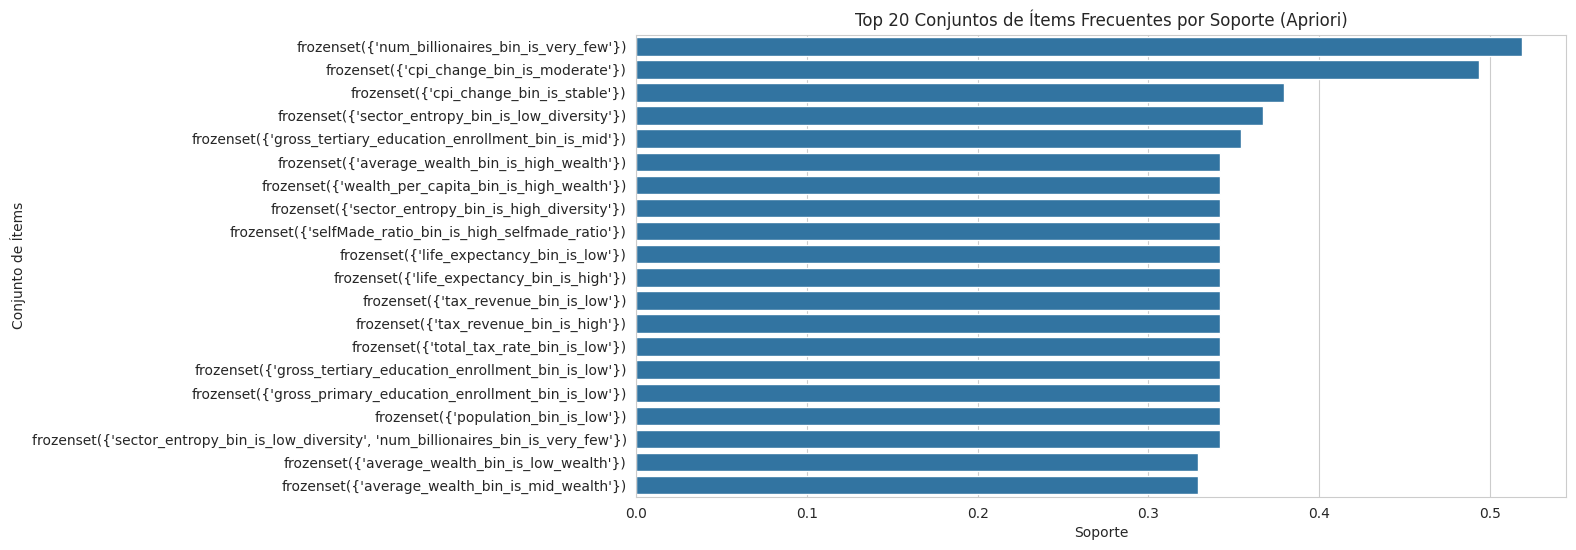

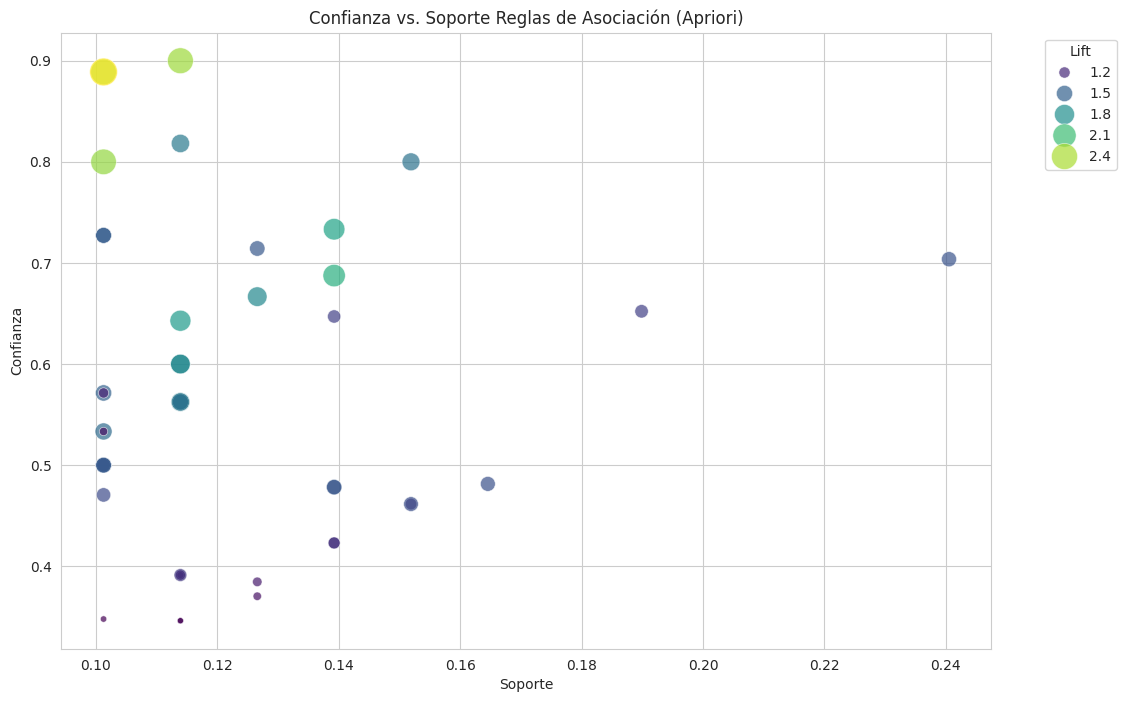

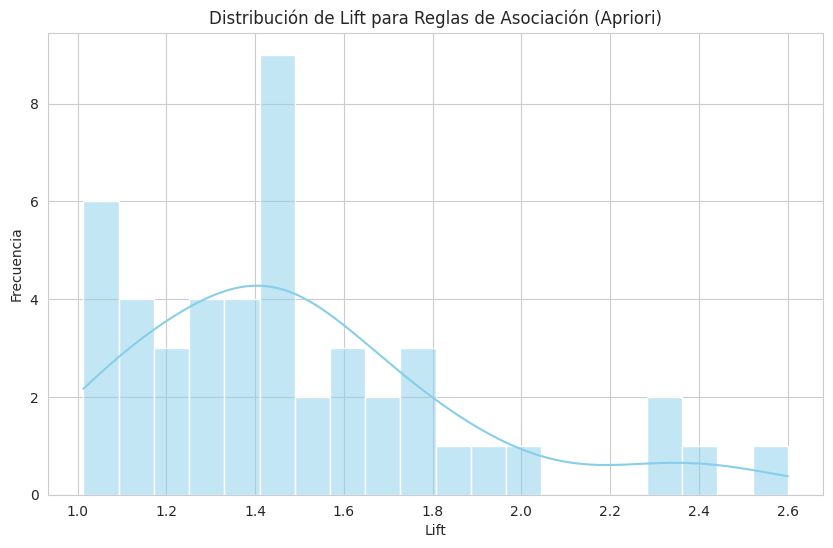

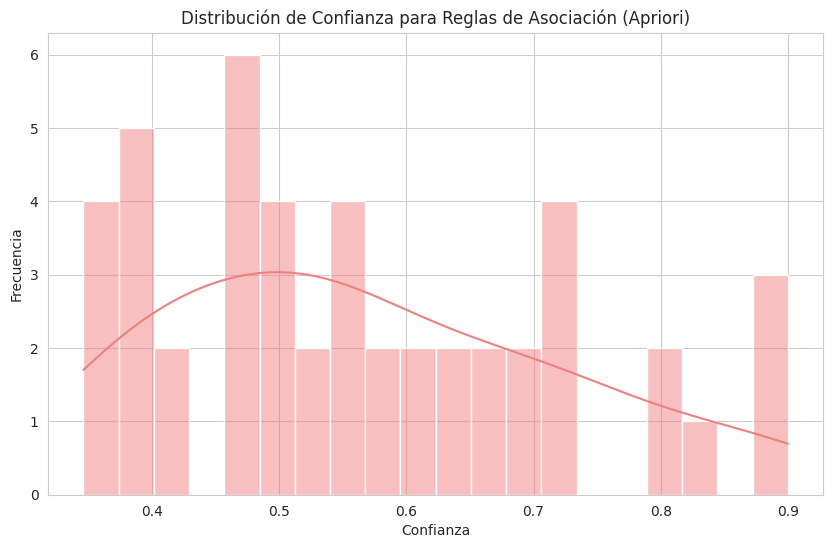

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Establecer el estilo de los gráficos
sns.set_style("whitegrid")

print("\n--- Resultados del Algoritmo Apriori ---")

# 1. Gráfico de los 10 Conjuntos de Ítems Frecuentes con mayor soporte
plt.figure(figsize=(12, 6))
sns.barplot(x='support', y='itemsets', data=frequent_itemsets.nlargest(20, 'support'))
plt.title('Top 20 Conjuntos de Ítems Frecuentes por Soporte (Apriori)')
plt.xlabel('Soporte')
plt.ylabel('Conjunto de Ítems')
plt.savefig('top_20_frequent_itemsets.png')
plt.show()

# 2. Gráfico de Dispersión de Confianza vs. Soporte para las Reglas Refinadas de Apriori
plt.figure(figsize=(12, 8))
sns.scatterplot(x='support', y='confidence', size='lift', data=refined_rules, hue='lift', sizes=(20, 400), palette='viridis', alpha=0.7)
plt.title('Confianza vs. Soporte Reglas de Asociación (Apriori)')
plt.xlabel('Soporte')
plt.ylabel('Confianza')
plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.savefig('confidence_vs_support_refined_rules.png')
plt.show()

# 3. Histograma de Lift para las Reglas Refinadas de Apriori
plt.figure(figsize=(10, 6))
sns.histplot(refined_rules['lift'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de Lift para Reglas de Asociación (Apriori)')
plt.xlabel('Lift')
plt.ylabel('Frecuencia')
plt.savefig('distribution_lift_refined_rules.png')
plt.show()

# 4. Histograma de Confianza para las Reglas Refinadas de Apriori
plt.figure(figsize=(10, 6))
sns.histplot(refined_rules['confidence'], bins=20, kde=True, color='lightcoral')
plt.title('Distribución de Confianza para Reglas de Asociación (Apriori)')
plt.xlabel('Confianza')
plt.ylabel('Frecuencia')
plt.savefig('distribution_confidence_refined_rules.png')
plt.show()

# **Second Method: FP-Growt**

FP-Growth es un algoritmo de asociación que trabaja sobre variables discretas o tambien llamadas categóricas por lo que usaremos el mismo dataset de transacciones que se generó en los primeros pasos del método anterior.

## Obtener Dataset Transactional

Creado en los primeros pasos de transformación del dataset del anterior método.

In [ ]:
final_transactional_df_cleaned.head()

,share_consumer_discretionary_bin_is_high,share_consumer_discretionary_bin_is_low,share_consumer_discretionary_bin_is_mid,share_consumer_staples_bin_is_high,share_consumer_staples_bin_is_low,share_consumer_staples_bin_is_mid,share_energy_&_natural_resources_bin_is_high,share_energy_&_natural_resources_bin_is_low,share_energy_&_natural_resources_bin_is_mid,share_financials_&_investments_bin_is_high,...,total_tax_rate_bin_is_high,gross_tertiary_education_enrollment_bin_is_low,gross_tertiary_education_enrollment_bin_is_mid,gross_tertiary_education_enrollment_bin_is_high,gross_primary_education_enrollment_bin_is_low,gross_primary_education_enrollment_bin_is_mid,gross_primary_education_enrollment_bin_is_high,population_bin_is_low,population_bin_is_mid,population_bin_is_high
country,,,,,,,,,,,,,,,,,,,,,
France,False,False,True,True,False,False,False,True,False,False,...,True,False,True,False,False,True,False,False,True,False
United States,False,False,True,False,False,True,False,False,True,False,...,False,False,False,True,False,True,False,False,False,True
Mexico,False,True,False,True,False,False,False,False,False,False,...,True,True,False,False,False,False,True,False,False,True
India,False,False,True,False,False,True,False,False,False,False,...,True,True,False,False,False,False,True,False,False,True
Spain,True,False,False,False,False,True,False,False,False,False,...,True,False,False,True,False,True,False,False,True,False


## Verificar Familiar de Bins

Los elementos de la familia deben ser mutuamente exclusivos, por lo que si un bien de esa familia es uno, los demás deben ser 0.

In [ ]:
print("Verificando la exclusividad mutua de los bins...")

# Obtener todos los prefijos únicos de los bins
bin_prefixes = set()
for col in final_transactional_df_cleaned.columns:
    # Asumiendo que el prefijo termina antes de '_is_'
    if '_is_' in col:
        bin_prefixes.add(col.split('_is_')[0])

violations_found = False

for prefix in bin_prefixes:
    # Encontrar todas las columnas que pertenecen a este prefijo (familia de bins)
    related_bins = [col for col in final_transactional_df_cleaned.columns if col.startswith(prefix + '_is_')]

    if len(related_bins) > 1: # Solo tiene sentido verificar si hay más de un bin en la familia
        # Sumar los valores de los bins para cada fila (país)
        sum_of_bins = final_transactional_df_cleaned[related_bins].sum(axis=1)

        # Verificar si hay alguna suma mayor que 1
        if (sum_of_bins > 1).any():
            violations_found = True
            violating_countries = sum_of_bins[sum_of_bins > 1].index.tolist()
            print(f"\n¡Violación encontrada para la familia de bins '{prefix}'!")
            print(f"Países donde más de un bin está activo: {violating_countries}")
            # Mostrar los datos de los países que violan la regla para esa familia
            display(final_transactional_df_cleaned.loc[violating_countries, related_bins])


if not violations_found:
    print("\n¡Excelente! Todos los bins dentro de cada familia son mutuamente excluyentes (en cada fila, a lo sumo un bin es 1).")
else:
    print("\nSe encontraron violaciones de exclusividad mutua en algunas familias de bins. Revisa los detalles anteriores.")

Verificando la exclusividad mutua de los bins...

¡Excelente! Todos los bins dentro de cada familia son mutuamente excluyentes (en cada fila, a lo sumo un bin es 1).


## Ejecutar FP-Growth

In [ ]:
from mlxtend.frequent_patterns import fpgrowth

In [ ]:
from mlxtend.frequent_patterns import fpgrowth

# Aplicar FP-Growth para encontrar conjuntos de ítems frecuentes
frequent_itemsets_fp = fpgrowth(final_transactional_df_cleaned, min_support=0.1, use_colnames=True)

print("Conjuntos de ítems frecuentes encontrados (primeras 5 filas):")
display(frequent_itemsets_fp.head())

# Generar reglas de asociación a partir de los conjuntos de ítems frecuentes
rules_fp = association_rules(frequent_itemsets_fp, metric="lift", min_threshold=1)

print("\nReglas de asociación generadas con FP-Growth (primeras 5 filas, ordenadas por lift): ")
display(rules_fp.sort_values(by='lift', ascending=False).head())

# --- Filtrado de Reglas FP-Growth basado en el objetivo del usuario ---

# 1. Definir los prefijos de las variables permitidas para antecedentes y consecuentes
antecedent_prefixes_fp = [
    'share_',
    'selfMade_ratio_bin_'
]

consequent_prefixes_fp = [
    'life_expectancy_bin_is_',
    'cpi_change_bin_is_',
    'gross_tertiary_education_enrollment_bin_is_',
    'tax_revenue_bin_is_',
    'total_tax_rate_bin_is_'
]

# 2. Construir los conjuntos de columnas OHE permitidas
all_ohe_columns = set(final_transactional_df_cleaned.columns) # Usar las columnas del df limpio

allowed_antecedent_columns_fp = set()
for col in all_ohe_columns:
    for prefix in antecedent_prefixes_fp:
        if col.startswith(prefix):
            allowed_antecedent_columns_fp.add(col)
            break

allowed_consequent_columns_fp = set()
for col in all_ohe_columns:
    for prefix in consequent_prefixes_fp:
        if col.startswith(prefix):
            allowed_consequent_columns_fp.add(col)
            break

# Función para verificar si un frozenset contiene alguna cadena con 'mid'
def contains_mid_fp(itemset):
    return any('mid' in item for item in itemset)

# 3. Aplicar los filtros a las reglas de FP-Growth
refined_rules_fp = rules_fp[
    # Antecedentes solo de atributos de billonarios (estructura de riqueza/industria)
    rules_fp['antecedents'].apply(lambda x: x.issubset(allowed_antecedent_columns_fp)) &
    # Consecuentes solo de bienestar del país
    rules_fp['consequents'].apply(lambda x: x.issubset(allowed_consequent_columns_fp))
]

print(f"\nNúmero de reglas de asociación refinadas (FP-Growth) encontradas: {len(refined_rules_fp)}")
print("Reglas de asociación refinadas con FP-Growth (ordenadas por Lift y Confianza):")
display(refined_rules_fp.sort_values(by=['lift', 'confidence'], ascending=False))

Conjuntos de ítems frecuentes encontrados (primeras 5 filas):


,support,itemsets
0,0.379747,(cpi_change_bin_is_stable)
1,0.354430,(gross_tertiary_education_enrollment_bin_is_mid)
2,0.341772,(life_expectancy_bin_is_high)
3,0.341772,(tax_revenue_bin_is_high)
4,0.341772,(wealth_per_capita_bin_is_high_wealth)



Reglas de asociación generadas con FP-Growth (primeras 5 filas, ordenadas por lift): 


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
33348,(gross_tertiary_education_enrollment_bin_is_mi...,"(gdp_bin_is_high, gross_primary_education_enro...",0.126582,0.113924,0.113924,0.9,7.9,1.0,0.099503,8.860759,1.0,0.9,0.887143,0.95
66971,(gross_primary_education_enrollment_bin_is_mid...,"(population_bin_is_high, gross_tertiary_educat...",0.126582,0.113924,0.113924,0.9,7.9,1.0,0.099503,8.860759,1.0,0.9,0.887143,0.95
33344,(gross_primary_education_enrollment_bin_is_mid...,"(gdp_bin_is_high, gross_tertiary_education_enr...",0.126582,0.113924,0.113924,0.9,7.9,1.0,0.099503,8.860759,1.0,0.9,0.887143,0.95
33359,(gross_primary_education_enrollment_bin_is_mid...,"(population_bin_is_high, gross_tertiary_educat...",0.126582,0.113924,0.113924,0.9,7.9,1.0,0.099503,8.860759,1.0,0.9,0.887143,0.95
33328,(gross_primary_education_enrollment_bin_is_mid...,(gross_tertiary_education_enrollment_bin_is_mi...,0.126582,0.113924,0.113924,0.9,7.9,1.0,0.099503,8.860759,1.0,0.9,0.887143,0.95



Número de reglas de asociación refinadas (FP-Growth) encontradas: 109
Reglas de asociación refinadas con FP-Growth (ordenadas por Lift y Confianza):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
41838,(share_manufacturing_and_industrial_source_bin...,"(life_expectancy_bin_is_high, cpi_change_bin_i...",0.126582,0.291139,0.101266,0.800000,2.747826,1.0,0.064413,3.544304,0.728261,0.320000,0.717857,0.573913
61845,"(share_other_bin_is_high, share_technology_sou...",(gross_tertiary_education_enrollment_bin_is_low),0.113924,0.341772,0.101266,0.888889,2.600823,1.0,0.062330,5.924051,0.694643,0.285714,0.831197,0.592593
41796,(share_manufacturing_and_industrial_source_bin...,(cpi_change_bin_is_stable),0.126582,0.379747,0.113924,0.900000,2.370000,1.0,0.065855,6.202532,0.661836,0.290323,0.838776,0.600000
41814,"(share_industrials_&_manufacturing_bin_is_low,...",(cpi_change_bin_is_stable),0.113924,0.379747,0.101266,0.888889,2.340741,1.0,0.058004,5.582278,0.646429,0.258065,0.820862,0.577778
41799,(share_manufacturing_and_industrial_source_bin...,(life_expectancy_bin_is_high),0.126582,0.341772,0.101266,0.800000,2.340741,1.0,0.058004,3.291139,0.655797,0.275862,0.696154,0.548148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57764,(share_financials_&_investments_bin_is_mid),(cpi_change_bin_is_moderate),0.202532,0.493671,0.101266,0.500000,1.012821,1.0,0.001282,1.012658,0.015873,0.170213,0.012500,0.352564
444,(selfMade_ratio_bin_is_low_selfmade_ratio),(life_expectancy_bin_is_low),0.329114,0.341772,0.113924,0.346154,1.012821,1.0,0.001442,1.006701,0.018868,0.204545,0.006657,0.339744
447,(selfMade_ratio_bin_is_low_selfmade_ratio),(tax_revenue_bin_is_low),0.329114,0.341772,0.113924,0.346154,1.012821,1.0,0.001442,1.006701,0.018868,0.204545,0.006657,0.339744
42578,(selfMade_ratio_bin_is_mid_selfmade_ratio),(tax_revenue_bin_is_low),0.329114,0.341772,0.113924,0.346154,1.012821,1.0,0.001442,1.006701,0.018868,0.204545,0.006657,0.339744


## Imprimir Reglas Ordenadar Por Lift y Confianza

In [ ]:
print("\nReglas de asociación con FP-Growth:\n")
# Display top 20 rules
for i, rule in refined_rules_fp.sort_values(by=['lift', 'confidence'], ascending=False).iterrows():
    antecedents_str = ', '.join(list(rule['antecedents']))
    consequents_str = ', '.join(list(rule['consequents']))
    print(f"Si un país tiene {antecedents_str}, entonces es probable que tenga {consequents_str}. (Confianza: {rule['confidence']:.2f}, Lift: {rule['lift']:.2f})")


Reglas de asociación con FP-Growth:

Si un país tiene share_manufacturing_and_industrial_source_bin_is_low, entonces es probable que tenga life_expectancy_bin_is_high, cpi_change_bin_is_stable. (Confianza: 0.80, Lift: 2.75)
Si un país tiene share_other_bin_is_high, share_technology_source_bin_is_high, entonces es probable que tenga gross_tertiary_education_enrollment_bin_is_low. (Confianza: 0.89, Lift: 2.60)
Si un país tiene share_manufacturing_and_industrial_source_bin_is_low, entonces es probable que tenga cpi_change_bin_is_stable. (Confianza: 0.90, Lift: 2.37)
Si un país tiene share_industrials_&_manufacturing_bin_is_low, share_manufacturing_and_industrial_source_bin_is_low, entonces es probable que tenga cpi_change_bin_is_stable. (Confianza: 0.89, Lift: 2.34)
Si un país tiene share_manufacturing_and_industrial_source_bin_is_low, entonces es probable que tenga life_expectancy_bin_is_high. (Confianza: 0.80, Lift: 2.34)
Si un país tiene share_other_bin_is_high, entonces es probable q

## Resultados del Algoritmo


--- FP-Growth Algorithm Results ---


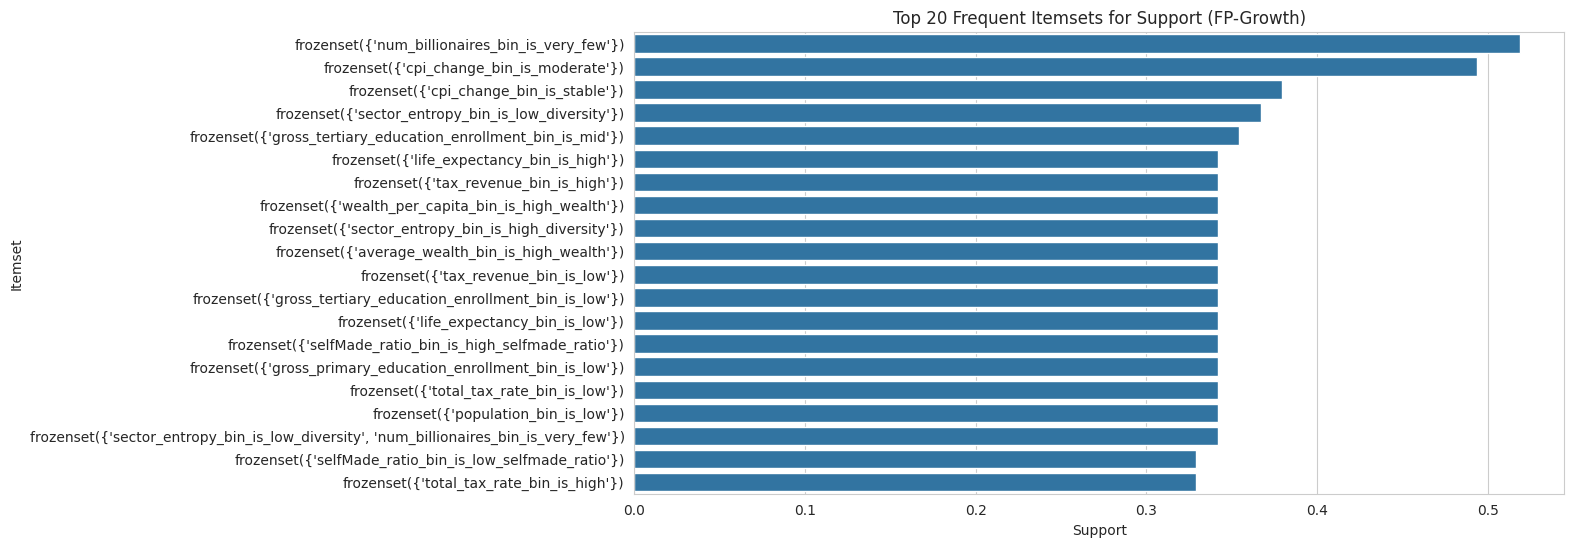

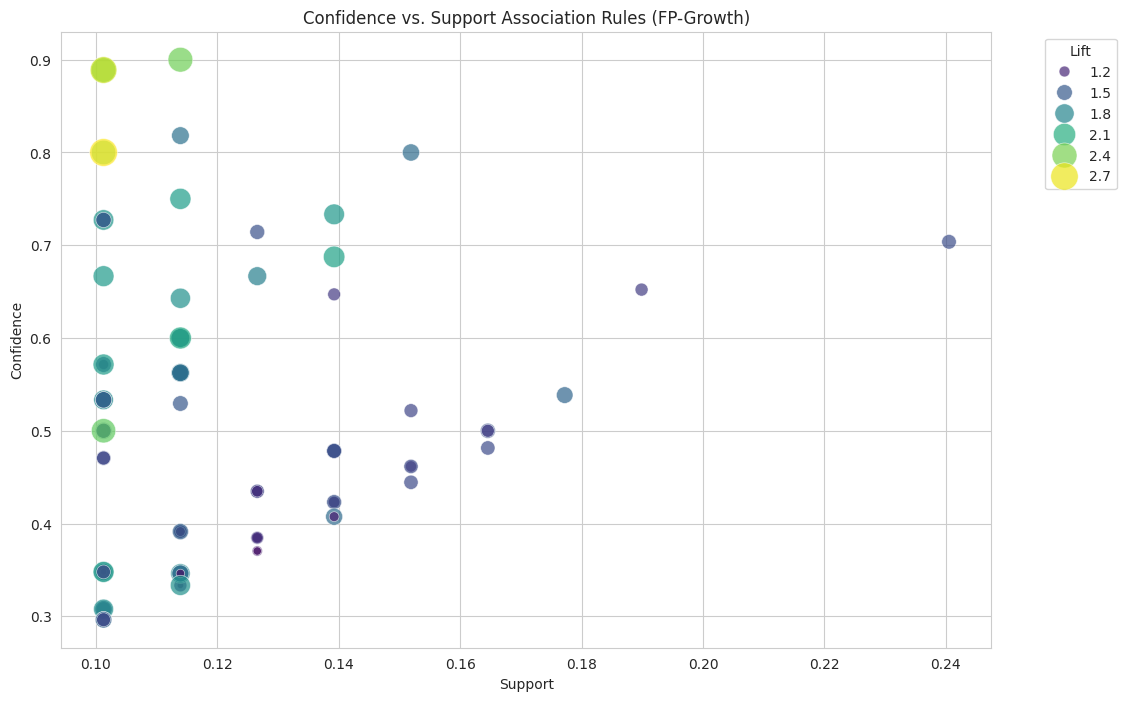

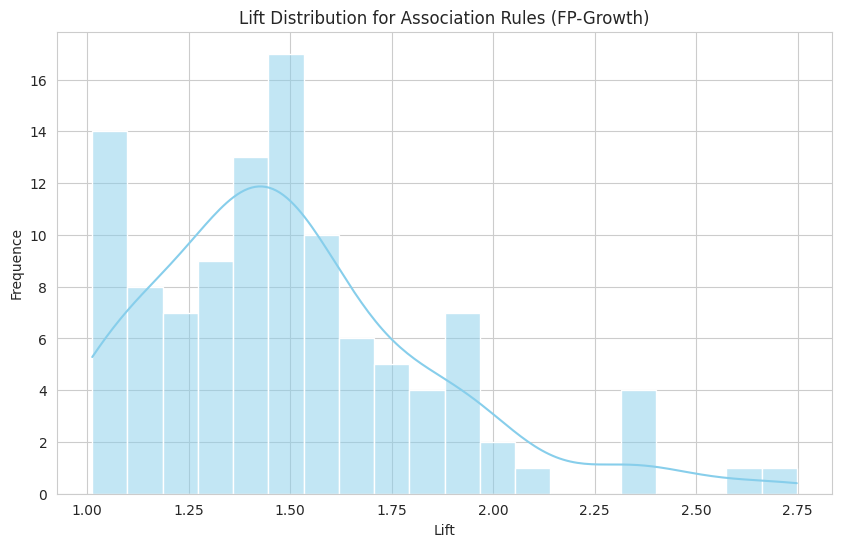

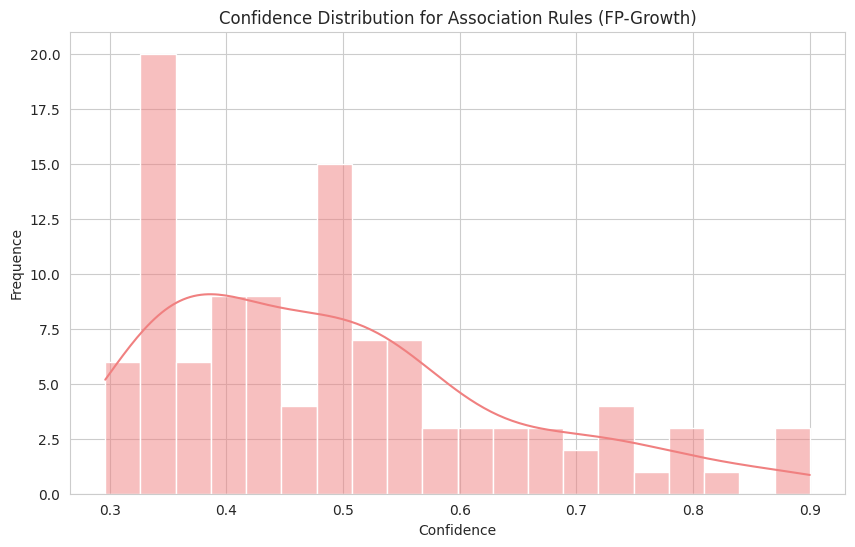

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Establecer el estilo de los gráficos
sns.set_style("whitegrid")

print("\n--- FP-Growth Algorithm Results ---")

# 1. Gráfico de los 10 Conjuntos de Ítems Frecuentes con mayor soporte
plt.figure(figsize=(12, 6))
sns.barplot(x='support', y='itemsets', data=frequent_itemsets_fp.nlargest(20, 'support'))
plt.title('Top 20 Frequent Itemsets for Support (FP-Growth)')
plt.xlabel('Support')
plt.ylabel('Itemset')
plt.show()

# 2. Gráfico de Dispersión de Confianza vs. Soporte para las Reglas Refinadas de FP-Growth
plt.figure(figsize=(12, 8))
sns.scatterplot(x='support', y='confidence', size='lift', data=refined_rules_fp, hue='lift', sizes=(20, 400), palette='viridis', alpha=0.7)
plt.title('Confidence vs. Support Association Rules (FP-Growth)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# 3. Histograma de Lift para las Reglas Refinadas de FP-Growth
plt.figure(figsize=(10, 6))
sns.histplot(refined_rules_fp['lift'], bins=20, kde=True, color='skyblue')
plt.title('Lift Distribution for Association Rules (FP-Growth)')
plt.xlabel('Lift')
plt.ylabel('Frequence')
plt.show()

# 4. Histograma de Confianza para las Reglas Refinadas de FP-Growth
plt.figure(figsize=(10, 6))
sns.histplot(refined_rules_fp['confidence'], bins=20, kde=True, color='lightcoral')
plt.title('Confidence Distribution for Association Rules (FP-Growth)')
plt.xlabel('Confidence')
plt.ylabel('Frequence')
plt.show()


## Interpretación y Hallazgos

A continuación veremos las 20 reglas más interesantes que se han encontrado después de ejecutar el algoritmo.

1. **Low industrial dependence associated with inflation stability and high life expectancy**

   $$
   \text{share_manufacturing_and_industrial_source_bin_is_low}
   \rightarrow
   \text{cpi_change_bin_is_stable}, \text{life_expectancy_bin_is_high}
   $$

   - **Confidence:** 0.80  
   - **Lift:** 2.75  

   This rule suggests that countries with low dependence on manufacturing and industrial wealth tend to simultaneously exhibit stable inflation and high life expectancy. The high lift value indicates a strong structural relationship between reduced industrial concentration and favorable socioeconomic conditions. This may reflect the characteristics of post-industrial economies, where wealth generation is more strongly linked to services, technology, or finance rather than heavy industry.

---

2. **High technological presence and “other” sectors associated with low tertiary education enrollment**

   $$
   \text{share_other_bin_is_high}
   \land
   \text{share_technology_source_bin_is_high}
   \rightarrow
   \text{gross_tertiary_education_enrollment_bin_is_low}
   $$

   - **Confidence:** 0.89  
   - **Lift:** 2.60  

   This was one of the strongest and most unexpected associations identified. It indicates that countries with high technological wealth combined with poorly defined economic sectors frequently present low levels of tertiary education enrollment. The result may suggest concentrated technological wealth structures where economic growth is not necessarily accompanied by broad educational access or institutional educational development.

---

3. **Low industrial dependence related to inflation stability**

   $$
   \text{share_manufacturing_and_industrial_source_bin_is_low}
   \rightarrow
   \text{cpi_change_bin_is_stable}
   $$

   - **Confidence:** 0.90  
   - **Lift:** 2.37  

   Countries with lower participation of industrial wealth tend to maintain stable inflation levels. This association may indicate that economies less dependent on manufacturing activities are less vulnerable to supply chain disruptions, raw material shocks, and industrial production costs that often generate inflationary pressures.

---

4. **Lower manufacturing presence associated with economic stability**

   $$
   \text{share_industrials_&_manufacturing_bin_is_low}
   \land
   \text{share_manufacturing_and_industrial_source_bin_is_low}
   \rightarrow
   \text{cpi_change_bin_is_stable}
   $$

   - **Confidence:** 0.89  
   - **Lift:** 2.34  

   The combination of low manufacturing participation across both industrial structure variables strongly reinforces the relationship with inflation stability. This rule suggests that reduced industrial concentration may contribute to more resilient and balanced macroeconomic environments.

---

5. **Low industrial orientation linked to higher life expectancy**

   $$
   \text{share_manufacturing_and_industrial_source_bin_is_low}
   \rightarrow
   \text{life_expectancy_bin_is_high}
   $$

   - **Confidence:** 0.80  
   - **Lift:** 2.34  

   Countries less dependent on industrial wealth tend to show higher life expectancy. This may reflect reduced exposure to pollution, industrial hazards, and unhealthy urban-industrial environments, as well as stronger development of healthcare and social service sectors.

---

6. **High presence of “other” sectors associated with low life expectancy and low tertiary education enrollment**

   $$
   \text{share_other_bin_is_high}
   \rightarrow
   \text{life_expectancy_bin_is_low},
   \text{gross_tertiary_education_enrollment_bin_is_low}
   $$

   - **Confidence:** 0.50  
   - **Lift:** 2.32  

   This rule reveals a potentially important structural pattern: countries with large participation of poorly categorized or “other” sectors tend to simultaneously present weaker educational outcomes and lower life expectancy. Such economies may be characterized by lower institutional maturity, economic informality, or limited diversification into advanced sectors.

---

7. **Low presence of “other” sectors associated with economic and social stability**

   $$
   \text{share_other_bin_is_low}
   \rightarrow
   \text{cpi_change_bin_is_stable},
   \text{life_expectancy_bin_is_high}
   $$

   - **Confidence:** 0.60  
   - **Lift:** 2.06  

   Countries with lower participation of undefined economic sectors tend to combine inflation stability with high life expectancy. This may indicate that economies with clearer specialization and stronger industrial or institutional structures are associated with better overall social conditions.

---

8. **High “other” sector participation associated with low tertiary education enrollment**

   $$
   \text{share_other_bin_is_high}
   \rightarrow
   \text{gross_tertiary_education_enrollment_bin_is_low}
   $$

   - **Confidence:** 0.69  
   - **Lift:** 2.01  

   A high presence of sectors categorized as “other” is strongly linked to low tertiary education enrollment. This may suggest economies with weaker knowledge-based industries, lower educational investment, or limited access to advanced academic systems.

---

9. **Moderate self-made wealth and low industrialization associated with inflation stability**

   $$
   \text{share_industrials_&_manufacturing_bin_is_low}
   \land
   \text{selfMade_ratio_bin_is_mid_selfmade_ratio}
   \rightarrow
   \text{cpi_change_bin_is_stable}
   $$

   - **Confidence:** 0.75  
   - **Lift:** 1.97  

   Countries with low manufacturing concentration and moderate levels of self-made wealth tend to exhibit stable inflation. This combination may characterize balanced economies where entrepreneurial activity exists without excessive industrial dependence or economic overheating.

---

10. **Consumer discretionary sectors associated with stable inflation and high life expectancy**

   $$
   \text{share_consumer_discretionary_bin_is_high}
   \rightarrow
   \text{cpi_change_bin_is_stable},
   \text{life_expectancy_bin_is_high}
   $$

   - **Confidence:** 0.57  
   - **Lift:** 1.96  

   A strong presence of consumer discretionary industries appears associated with both economic stability and better social well-being indicators. Consumer-driven economies often emerge in countries with stronger purchasing power, larger middle classes, and more developed service sectors.

---

11. **High financial sector participation associated with moderate inflation and medium tax revenue**

   $$
   \text{share_finance_and_investments_source_bin_is_high}
   \rightarrow
   \text{tax_revenue_bin_is_mid},
   \text{cpi_change_bin_is_moderate}
   $$

   - **Confidence:** 0.35  
   - **Lift:** 1.96  

   Countries with strong financial sectors tend to present moderate inflation and medium levels of tax revenue. This may reflect economies characterized by active capital circulation, investment activity, and relatively balanced fiscal systems.

---

12. **Moderate self-made wealth and low manufacturing associated with high life expectancy**

   $$
   \text{share_industrials_&_manufacturing_bin_is_low}
   \land
   \text{selfMade_ratio_bin_is_mid_selfmade_ratio}
   \rightarrow
   \text{life_expectancy_bin_is_high}
   $$

   - **Confidence:** 0.67  
   - **Lift:** 1.95  

   This rule suggests that countries combining moderate entrepreneurial wealth generation with lower industrial dependence tend to achieve better life expectancy outcomes. Such economies may balance economic dynamism with social stability and quality-of-life improvements.

---

13. **Low manufacturing concentration associated with inflation stability**

   $$
   \text{share_industrials_\&_manufacturing_bin_is_low}
   \rightarrow
   \text{cpi_change_bin_is_stable}
   $$

   - **Confidence:** 0.73  
   - **Lift:** 1.93  

   Economies with lower manufacturing concentration frequently exhibit controlled inflation. This reinforces the broader pattern observed throughout the analysis that reduced industrial dependence may contribute to more stable macroeconomic environments.

---

14. **Low “other” sector participation and moderate self-made wealth associated with inflation stability**

   $$
   \text{share_other_bin_is_low}
   \land
   \text{selfMade_ratio_bin_is_mid_selfmade_ratio}
   \rightarrow
   \text{cpi_change_bin_is_stable}
   $$

   - **Confidence:** 0.73  
   - **Lift:** 1.92  

   Countries with more structured economies and moderate levels of self-made wealth tend to present stable inflationary conditions. This may indicate balanced economic systems where entrepreneurship develops alongside institutional and macroeconomic stability.

---

15. **Consumer discretionary sectors associated with high life expectancy**

   $$
   \text{share_consumer_discretionary_bin_is_high}
   \rightarrow
   \text{life_expectancy_bin_is_high}
   $$

   - **Confidence:** 0.64  
   - **Lift:** 1.88  

   Countries with strong consumer discretionary sectors tend to display higher life expectancy. This relationship may reflect higher disposable income, improved access to healthcare and services, and stronger general living conditions commonly found in advanced consumer-oriented economies.

---

16. **High self-made wealth associated with moderate inflation and medium tax revenue**

   $$
   \text{selfMade_ratio_bin_is_high_selfmade_ratio}
   \rightarrow
   \text{tax_revenue_bin_is_mid},
   \text{cpi_change_bin_is_moderate}
   $$

   - **Confidence:** 0.33  
   - **Lift:** 1.88  

   Countries with high proportions of self-made wealth tend to coexist with moderately inflationary environments and intermediate fiscal revenue levels. This may indicate dynamic entrepreneurial economies characterized by strong economic activity, market expansion, and increased capital circulation.

---

17. **Moderate self-made wealth associated with low taxation and high life expectancy**

   $$
   \text{selfMade_ratio_bin_is_mid_selfmade_ratio}
   \rightarrow
   \text{total_tax_rate_bin_is_low},
   \text{life_expectancy_bin_is_high}
   $$

   - **Confidence:** 0.31  
   - **Lift:** 1.87  

   This rule suggests that countries with moderate levels of self-made wealth often combine favorable social conditions with relatively lower tax burdens. Such economies may achieve a balance between entrepreneurial activity, economic competitiveness, and quality-of-life outcomes.

---

18. **Low industrial concentration associated with inflation stability and high life expectancy**

   $$
   \text{share_industrials_\&_manufacturing_bin_is_low}
   \rightarrow
   \text{cpi_change_bin_is_stable},
   \text{life_expectancy_bin_is_high}
   $$

   - **Confidence:** 0.53  
   - **Lift:** 1.83  

   Countries with lower manufacturing concentration tend to exhibit both stable inflation and higher life expectancy. This further supports the recurring pattern linking post-industrial or diversified economies with improved macroeconomic and social indicators.

---

19. **Medium financial sector participation associated with low taxes and stable inflation**

   $$
   \text{share_finance_and_investments_source_bin_is_mid}
   \rightarrow
   \text{total_tax_rate_bin_is_low},
   \text{cpi_change_bin_is_stable}
   $$

   - **Confidence:** 0.35  
   - **Lift:** 1.83  

   Countries with moderate financial sector participation tend to display relatively low tax burdens and stable inflation levels. This may characterize balanced financial systems that promote investment and economic stability without excessive market concentration.

---

20. **Moderate self-made wealth associated with low taxes and inflation stability**

   $$
   \text{selfMade_ratio_bin_is_mid_selfmade_ratio}
   \rightarrow
   \text{total_tax_rate_bin_is_low},
   \text{cpi_change_bin_is_stable}
   $$

   - **Confidence:** 0.35  
   - **Lift:** 1.82  

   This association indicates that countries with moderate levels of self-made wealth often coexist with stable macroeconomic environments and lower taxation levels. The result may reflect economies where entrepreneurial activity develops within relatively efficient and predictable economic systems.